# 🧹 Data Preparation — Employee Attrition Risk Prediction
**Dikerjakan oleh:** Zahra Daniah

**Tanggung jawab:**
- ✅ Data Cleaning
- ✅ Data Preprocessing
- ✅ Feature Engineering

**Dataset:** [Employee Attrition Prediction Dataset](https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset)

---

## 📦 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 📂 2. Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('../data/employee_attrition_dataset_10000.csv')

print(f'📊 Shape dataset: {df.shape}')
print(f'📋 Jumlah baris: {df.shape[0]}')
print(f'📋 Jumlah kolom: {df.shape[1]}')
df.head()

📊 Shape dataset: (10000, 26)
📋 Jumlah baris: 10000
📋 Jumlah kolom: 26


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [3]:
# Simpan salinan awal sebelum preprocessing
df_original = df.copy()

# Informasi umum dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    10000 non-null  int64
 1   Age                            10000 non-null  int64
 2   Gender                         10000 non-null  str  
 3   Marital_Status                 10000 non-null  str  
 4   Department                     10000 non-null  str  
 5   Job_Role                       10000 non-null  str  
 6   Job_Level                      10000 non-null  int64
 7   Monthly_Income                 10000 non-null  int64
 8   Hourly_Rate                    10000 non-null  int64
 9   Years_at_Company               10000 non-null  int64
 10  Years_in_Current_Role          10000 non-null  int64
 11  Years_Since_Last_Promotion     10000 non-null  int64
 12  Work_Life_Balance              10000 non-null  int64
 13  Job_Satisfaction            

In [4]:
# Statistik deskriptif
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Age,10000.0,NaN,NaN,NaN,39.5618,11.454986,20.0,30.0,40.0,49.0,59.0
Gender,10000,2,Female,5042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,10000,3,Married,3375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,10000,5,Marketing,2133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Role,10000,4,Analyst,2572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Level,10000.0,NaN,NaN,NaN,2.9908,1.410643,1.0,2.0,3.0,4.0,5.0
Monthly_Income,10000.0,NaN,NaN,NaN,11436.7167,4926.528302,3000.0,7182.5,11401.5,15679.5,19999.0
Hourly_Rate,10000.0,NaN,NaN,NaN,57.0323,24.703261,15.0,36.0,57.0,78.0,99.0
Years_at_Company,10000.0,NaN,NaN,NaN,14.9362,8.431657,1.0,8.0,15.0,22.0,29.0


---
## 🧹 3. DATA CLEANING

### 3.1 Cek & Tangani Missing Values

In [5]:
# Hitung missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
}).sort_values('Missing (%)', ascending=False)

print('=== MISSING VALUES ===')
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print('✅ Tidak ada missing values!')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []
✅ Tidak ada missing values!


In [6]:
# Visualisasi missing values
plt.figure(figsize=(12, 5))
missing_plot = missing_pct[missing_pct > 0]

if len(missing_plot) > 0:
    missing_plot.plot(kind='bar', color='salmon')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Persentase (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('✅ Tidak ada missing values untuk divisualisasikan.')

✅ Tidak ada missing values untuk divisualisasikan.


<Figure size 1200x500 with 0 Axes>

In [7]:
# Penanganan missing values (jika ada)
# Kolom numerik: isi dengan median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'✅ {col}: missing diisi dengan median ({df[col].median():.2f})')

# Kolom kategorikal: isi dengan modus
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'✅ {col}: missing diisi dengan modus ({df[col].mode()[0]})')

print(f'\n✅ Total missing setelah penanganan: {df.isnull().sum().sum()}')


✅ Total missing setelah penanganan: 0


### 3.2 Cek & Hapus Duplikat

In [8]:
# Cek duplikat
dup_count = df.duplicated().sum()
print(f'🔍 Jumlah baris duplikat: {dup_count}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ Duplikat dihapus. Shape sekarang: {df.shape}')
else:
    print('✅ Tidak ada data duplikat!')

🔍 Jumlah baris duplikat: 0
✅ Tidak ada data duplikat!


### 3.3 Cek & Hapus Kolom Tidak Relevan

In [9]:
# Cek kolom dengan nilai unik tunggal (tidak informatif)
single_val_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f'Kolom dengan 1 nilai unik: {single_val_cols}')

# Hapus kolom ID (tidak relevan untuk modeling)
cols_to_drop = []

# Drop Employee_ID jika ada
if 'Employee_ID' in df.columns:
    cols_to_drop.append('Employee_ID')

# Drop kolom dengan 1 nilai unik
cols_to_drop.extend(single_val_cols)

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f'✅ Kolom dihapus: {cols_to_drop}')
    print(f'📊 Shape sekarang: {df.shape}')
else:
    print('✅ Tidak ada kolom yang perlu dihapus (selain ID)')
    # Tetap drop Employee_ID jika ada
    if 'Employee_ID' in df.columns:
        df.drop(columns=['Employee_ID'], inplace=True)
        print('✅ Employee_ID dihapus (kolom identifier, tidak untuk modeling)')

Kolom dengan 1 nilai unik: []
✅ Kolom dihapus: ['Employee_ID']
📊 Shape sekarang: (10000, 25)


### 3.4 Cek & Tangani Outlier

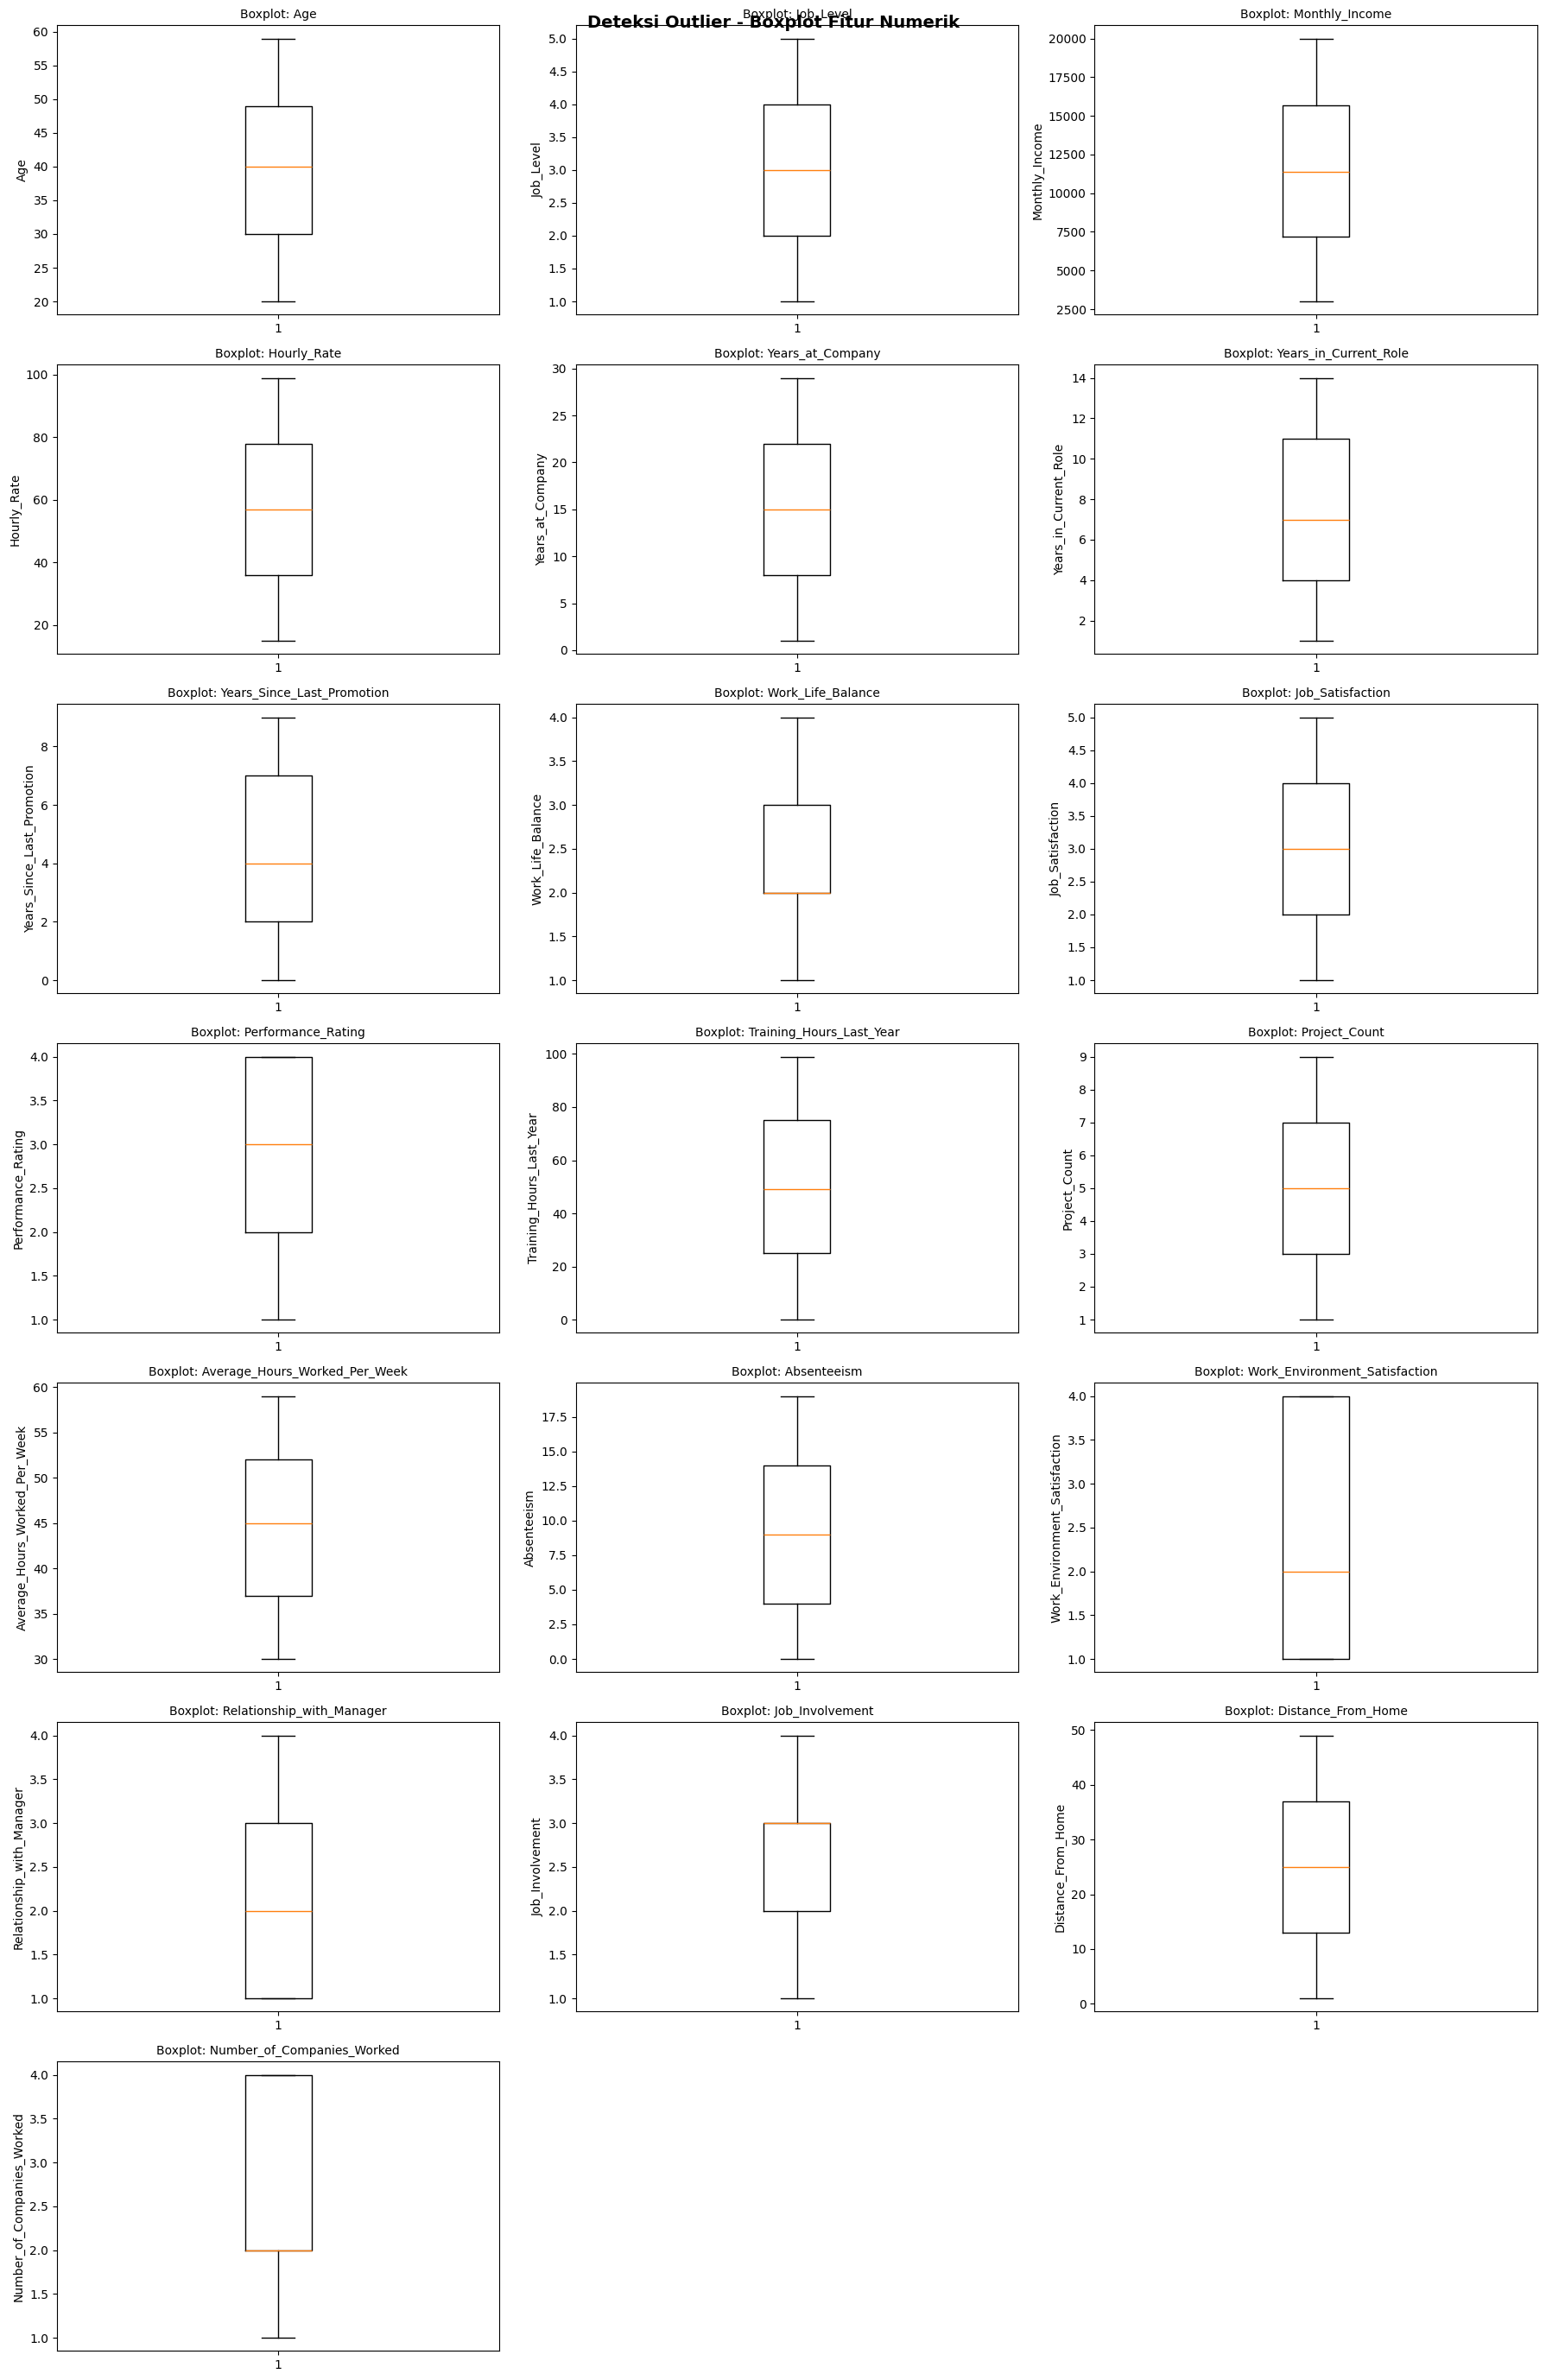

In [10]:
# Visualisasi outlier dengan boxplot
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Hapus target dari visualisasi outlier
target_col = 'Attrition'
num_features_plot = [col for col in num_features if col != target_col]

n_cols = 3
n_rows = (len(num_features_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features_plot):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}', fontsize=10)
    axes[i].set_ylabel(col)

# Sembunyikan axes kosong
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier - Boxplot Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Deteksi outlier dengan IQR dan tangani dengan capping (Winsorization)
def cap_outliers_iqr(df, col, lower_pct=0.01, upper_pct=0.99):
    """Cap outlier menggunakan percentile (lebih aman dari drop)."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    if n_outliers > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'  ⚠️  {col}: {n_outliers} outlier di-cap (lower={lower:.2f}, upper={upper:.2f})')
    
    return df

# Kolom yang perlu dicek outlier (skip rating 1-5 karena bounded)
bounded_cols = ['Job_Satisfaction', 'Performance_Rating', 'Work_Environment_Satisfaction',
                'Relationship_with_Manager', 'Job_Involvement', 'Job_Level']
outlier_cols = [col for col in num_features_plot if col not in bounded_cols]

print('=== PENANGANAN OUTLIER (IQR Capping) ===')
for col in outlier_cols:
    df = cap_outliers_iqr(df, col)

print('\n✅ Outlier selesai ditangani!')

=== PENANGANAN OUTLIER (IQR Capping) ===

✅ Outlier selesai ditangani!


### 3.5 Cek Konsistensi Data

In [12]:
# Cek nilai unik pada kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print('=== NILAI UNIK KOLOM KATEGORIKAL ===')
for col in cat_cols:
    print(f'\n📌 {col} ({df[col].nunique()} unik): {df[col].unique().tolist()}')

=== NILAI UNIK KOLOM KATEGORIKAL ===

📌 Gender (2 unik): ['Male', 'Female']

📌 Marital_Status (3 unik): ['Single', 'Divorced', 'Married']

📌 Department (5 unik): ['Finance', 'HR', 'Marketing', 'Sales', 'IT']

📌 Job_Role (4 unik): ['Manager', 'Assistant', 'Analyst', 'Executive']

📌 Overtime (2 unik): ['No', 'Yes']

📌 Attrition (2 unik): ['No', 'Yes']


In [13]:
# Standardisasi format teks (lowercase, strip whitespace)
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print('✅ Format teks kolom kategorikal sudah dirapikan.')

# Cek distribusi target
print('\n=== DISTRIBUSI TARGET (Attrition) ===')
if 'Attrition' in df.columns:
    print(df['Attrition'].value_counts())
    print(f'Proporsi: {df["Attrition"].value_counts(normalize=True).round(3).to_dict()}')

✅ Format teks kolom kategorikal sudah dirapikan.

=== DISTRIBUSI TARGET (Attrition) ===
Attrition
No     8003
Yes    1997
Name: count, dtype: int64
Proporsi: {'No': 0.8, 'Yes': 0.2}


---
## ⚙️ 4. DATA PREPROCESSING

### 4.1 Encoding Target Variable

In [14]:
# Encode target: Yes=1, No=0
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
    print('✅ Target Attrition di-encode: Yes=1, No=0')

print(f'Distribusi target setelah encoding:\n{df["Attrition"].value_counts()}')

Distribusi target setelah encoding:
Attrition
No     8003
Yes    1997
Name: count, dtype: int64


### 4.2 Encoding Fitur Kategorikal

In [15]:
# Identifikasi kolom kategorikal (kecuali target)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Attrition']

print(f'Kolom kategorikal yang akan di-encode: {cat_cols}')

# Binary encoding (kolom dengan 2 nilai unik)
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
# One-Hot encoding (kolom dengan >2 nilai unik)
onehot_cols = [col for col in cat_cols if df[col].nunique() > 2]

print(f'\nBinary encoding: {binary_cols}')
print(f'One-Hot encoding: {onehot_cols}')

Kolom kategorikal yang akan di-encode: ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']

Binary encoding: ['Gender', 'Overtime']
One-Hot encoding: ['Marital_Status', 'Department', 'Job_Role']


In [16]:
# Binary Encoding
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f'✅ Binary encode: {col} → {df[col].unique()}')

# One-Hot Encoding
if onehot_cols:
    df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
    print(f'\n✅ One-Hot encode selesai: {onehot_cols}')

print(f'\n📊 Shape setelah encoding: {df.shape}')
df.head()

✅ Binary encode: Gender → [1 0]
✅ Binary encode: Overtime → [0 1]

✅ One-Hot encode selesai: ['Marital_Status', 'Department', 'Job_Role']

📊 Shape setelah encoding: (10000, 31)


,Age,Gender,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Attrition,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager
0,58,1,5,7332,81,24,12,3,1,3,...,No,False,True,False,False,False,False,False,False,True
1,48,0,4,6069,55,18,7,5,1,2,...,No,False,False,True,False,False,False,True,False,False
2,34,0,4,11485,65,6,4,3,4,5,...,Yes,True,False,False,False,True,False,False,False,True
3,27,0,4,18707,28,12,9,1,1,1,...,No,False,False,True,False,False,False,False,False,True
4,40,1,1,16398,92,3,9,1,3,4,...,No,True,False,True,False,False,False,False,False,False


### 4.3 Pisah Fitur dan Target

In [17]:
# Pisah fitur (X) dan target (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f'✅ Shape X (fitur): {X.shape}')
print(f'✅ Shape y (target): {y.shape}')
print(f'\nDistribusi kelas target:')
print(y.value_counts())
print(f'  → Class 0 (No Attrition): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  → Class 1 (Attrition):    {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')

✅ Shape X (fitur): (10000, 30)
✅ Shape y (target): (10000,)

Distribusi kelas target:
Attrition
No     8003
Yes    1997
Name: count, dtype: int64
  → Class 0 (No Attrition): 0 (0.0%)
  → Class 1 (Attrition):    0 (0.0%)


### 4.4 Feature Scaling (Normalisasi)

In [18]:
# Identifikasi kolom numerik yang perlu di-scale
# (skip kolom boolean/dummy hasil encoding)
bool_cols = X.select_dtypes(include=['bool', 'uint8']).columns.tolist()
scale_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols = [col for col in scale_cols if col not in bool_cols]

# Gender & Overtime ke pengecualian ( sudah di-encode jadi 0 dan 1 )
binary_encoded = ['Gender', 'Overtime']
scale_cols = [col for col in scale_cols if col not in binary_encoded]

print(f'Kolom yang akan di-scale ({len(scale_cols)} kolom):')
print(scale_cols)

# StandardScaler (mean=0, std=1) — cocok untuk model berbasis jarak
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'\n✅ Scaling selesai dengan StandardScaler')
print(f'Contoh sebelum scaling (Monthly_Income):')
print(f'  Mean={X["Monthly_Income"].mean():.2f}, Std={X["Monthly_Income"].std():.2f}' if 'Monthly_Income' in X.columns else '')
print(f'Contoh setelah scaling:')
print(f'  Mean={X_scaled["Monthly_Income"].mean():.4f}, Std={X_scaled["Monthly_Income"].std():.4f}' if 'Monthly_Income' in X_scaled.columns else '')

Kolom yang akan di-scale (19 kolom):
['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']

✅ Scaling selesai dengan StandardScaler
Contoh sebelum scaling (Monthly_Income):
  Mean=11436.72, Std=4926.53
Contoh setelah scaling:
  Mean=-0.0000, Std=1.0001


---
## 🔧 5. FEATURE ENGINEERING

### 5.1 Buat Fitur Baru dari Kolom yang Ada

In [19]:
# Gunakan df sebelum scaling untuk feature engineering
df_fe = df.copy()

# ── FITUR 1: Salary-to-Experience Ratio
# Mengukur apakah karyawan dibayar sesuai pengalamannya
if 'Monthly_Income' in df_fe.columns and 'Years_at_Company' in df_fe.columns:
    df_fe['Salary_Experience_Ratio'] = df_fe['Monthly_Income'] / (df_fe['Years_at_Company'] + 1)
    print('✅ Salary_Experience_Ratio = Monthly_Income / (Years_at_Company + 1)')

# ── FITUR 2: Workload Score
# Gabungan jam kerja dan jumlah proyek — proxy burnout
if 'Average_Hours_Worked_Per_Week' in df_fe.columns and 'Project_Count' in df_fe.columns:
    df_fe['Workload_Score'] = df_fe['Average_Hours_Worked_Per_Week'] * df_fe['Project_Count']
    print('✅ Workload_Score = Average_Hours_Worked_Per_Week × Project_Count')

# ── FITUR 3: Job Satisfaction Index
# Rata-rata kepuasan keseluruhan karyawan
satisfaction_cols = ['Job_Satisfaction', 'Work_Environment_Satisfaction',
                     'Relationship_with_Manager', 'Job_Involvement']
available_sat = [col for col in satisfaction_cols if col in df_fe.columns]
if available_sat:
    df_fe['Overall_Satisfaction_Index'] = df_fe[available_sat].mean(axis=1)
    print(f'✅ Overall_Satisfaction_Index = mean({available_sat})')

# ── FITUR 4: Career Stagnation
# Lama di role yang sama vs total di perusahaan
if 'Years_in_Current_Role' in df_fe.columns and 'Years_at_Company' in df_fe.columns:
    df_fe['Career_Stagnation_Ratio'] = df_fe['Years_in_Current_Role'] / (df_fe['Years_at_Company'] + 1)
    print('✅ Career_Stagnation_Ratio = Years_in_Current_Role / (Years_at_Company + 1)')

# ── FITUR 5: High Workload Flag
# Flag biner: karyawan bekerja >45 jam/minggu
if 'Average_Hours_Worked_Per_Week' in df_fe.columns:
    df_fe['Is_Overworked'] = (df_fe['Average_Hours_Worked_Per_Week'] > 45).astype(int)
    print('✅ Is_Overworked = 1 jika Average_Hours_Worked_Per_Week > 45')

# ── FITUR 6: Absenteeism Risk
# Flag absensi tinggi (>5 hari)
if 'Absenteeism' in df_fe.columns:
    df_fe['High_Absenteeism'] = (df_fe['Absenteeism'] > 5).astype(int)
    print('✅ High_Absenteeism = 1 jika Absenteeism > 5 hari')

# ── FITUR 7: Age Group
# Binning usia menjadi kategori generasi
if 'Age' in df_fe.columns:
    bins = [0, 25, 35, 45, 100]
    labels = ['Gen_Z', 'Millennial', 'Gen_X', 'Boomer']
    df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels, right=False)
    df_fe = pd.get_dummies(df_fe, columns=['Age_Group'], drop_first=True)
    print('✅ Age_Group = binning usia (Gen_Z / Millennial / Gen_X / Boomer)')

print(f'\n📊 Shape setelah feature engineering: {df_fe.shape}')

✅ Salary_Experience_Ratio = Monthly_Income / (Years_at_Company + 1)
✅ Workload_Score = Average_Hours_Worked_Per_Week × Project_Count
✅ Overall_Satisfaction_Index = mean(['Job_Satisfaction', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement'])
✅ Career_Stagnation_Ratio = Years_in_Current_Role / (Years_at_Company + 1)
✅ Is_Overworked = 1 jika Average_Hours_Worked_Per_Week > 45
✅ High_Absenteeism = 1 jika Absenteeism > 5 hari
✅ Age_Group = binning usia (Gen_Z / Millennial / Gen_X / Boomer)

📊 Shape setelah feature engineering: (10000, 40)


### 5.2 Ringkasan Fitur Baru

In [20]:
new_features = [
    'Salary_Experience_Ratio', 'Workload_Score', 'Overall_Satisfaction_Index',
    'Career_Stagnation_Ratio', 'Is_Overworked', 'High_Absenteeism'
]
existing_new = [f for f in new_features if f in df_fe.columns]

print('=== STATISTIK FITUR BARU ===')
print(df_fe[existing_new].describe().round(3))

=== STATISTIK FITUR BARU ===
       Salary_Experience_Ratio  Workload_Score  Overall_Satisfaction_Index  \
count                10000.000       10000.000                   10000.000   
mean                  1190.012         221.810                       2.632   
std                   1379.129         124.768                       0.595   
min                    101.500          30.000                       1.000   
25%                    433.982         114.000                       2.250   
50%                    716.925         216.000                       2.750   
75%                   1322.000         312.000                       3.000   
max                   9989.500         531.000                       4.250   

       Career_Stagnation_Ratio  Is_Overworked  High_Absenteeism  
count                10000.000      10000.000         10000.000  
mean                     0.778          0.467             0.694  
std                      0.967          0.499             0.461  
min 

### 5.3 Korelasi Fitur Baru dengan Target

In [21]:
# Korelasi fitur baru terhadap target Attrition
target_corr = df_fe[existing_new + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title('Korelasi Fitur Baru terhadap Attrition', fontsize=13, fontweight='bold')
plt.xlabel('Korelasi')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Nilai korelasi fitur baru:')
print(target_corr.round(4))

ValueError: could not convert string to float: 'No'

### 5.4 Re-scaling Setelah Feature Engineering

In [ ]:
# Pisah ulang X dan y dari df_fe
X_final = df_fe.drop(columns=['Attrition'])
y_final = df_fe['Attrition']

# Scale ulang semua kolom numerik
bool_cols_fe = X_final.select_dtypes(include=['bool', 'uint8']).columns.tolist()
scale_cols_fe = X_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols_fe = [col for col in scale_cols_fe if col not in bool_cols_fe]

scaler_final = StandardScaler()
X_final_scaled = X_final.copy()
X_final_scaled[scale_cols_fe] = scaler_final.fit_transform(X_final[scale_cols_fe])

print(f'✅ Final X shape (siap untuk modeling): {X_final_scaled.shape}')
print(f'✅ Final y shape: {y_final.shape}')
X_final_scaled.head()

✅ Final X shape (siap untuk modeling): (10000, 39)
✅ Final y shape: (10000,)


,Age,Gender,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Job_Role_Manager,Salary_Experience_Ratio,Workload_Score,Overall_Satisfaction_Index,Career_Stagnation_Ratio,Is_Overworked,High_Absenteeism,Age_Group_Millennial,Age_Group_Gen_X,Age_Group_Boomer
0,1.609703,1.008436,1.424386,-0.833228,0.970273,1.075026,1.125164,-0.509049,-1.350724,-0.026861,...,True,-0.650248,1.684730,-0.642087,-0.308453,1.069188,0.664332,False,False,True
1,0.736677,-0.991635,0.715454,-1.089608,-0.082273,0.363387,-0.111633,0.182641,-1.350724,-0.733728,...,False,-0.631293,2.333968,-1.062328,-0.423841,1.069188,0.664332,False,False,True
2,-0.485560,-0.991635,0.715454,0.009801,0.322552,-1.059892,-0.853711,-0.509049,1.346409,1.386873,...,True,0.326818,-0.455353,1.038879,-0.213904,1.069188,-1.505271,True,False,False
3,-1.096678,-0.991635,0.715454,1.475816,-1.175300,-0.348253,0.383086,-1.200738,-1.350724,-1.440595,...,True,0.180549,2.045418,-0.642087,-0.088899,1.069188,-1.505271,True,False,False
4,0.038256,1.008436,-1.411342,1.007105,1.415580,-1.415712,0.383086,-1.200738,0.447364,0.680006,...,False,2.109761,-1.345050,-1.482570,1.521961,1.069188,0.664332,False,True,False


---
## 💾 6. Simpan Hasil Data Preparation

In [ ]:
# Simpan dataset bersih + hasil feature engineering
df_fe.to_csv('../data/employee_attrition_clean.csv', index=False)
X_final_scaled.to_csv('../data/X_preprocessed.csv', index=False)
y_final.to_csv('../data/y_target.csv', index=False)

print('✅ File tersimpan:')
print('  - employee_attrition_clean.csv  → dataset lengkap setelah cleaning + FE')
print('  - X_preprocessed.csv           → fitur siap modeling (sudah scaled)')
print('  - y_target.csv                 → label target')

✅ File tersimpan:
  - employee_attrition_clean.csv  → dataset lengkap setelah cleaning + FE
  - X_preprocessed.csv           → fitur siap modeling (sudah scaled)
  - y_target.csv                 → label target


---
## 📋 7. Ringkasan Data Preparation

In [ ]:
print('=' * 55)
print('RINGKASAN DATA PREPARATION '.center(55))
print('=' * 55)

print(f'\n📌 DATASET AWAL')
print(f'   Shape         : {df_original.shape}')

print(f'\n🧹 DATA CLEANING')
print(f'   Missing values: Ditangani (median/modus)')
print(f'   Duplikat      : Dihapus')
print(f'   Kolom ID      : Dihapus (Employee_ID)')
print(f'   Outlier       : Di-cap dengan IQR method')

print(f'\n⚙️  DATA PREPROCESSING')
print(f'   Target encode : Yes=1, No=0')
print(f'   Cat. encode   : Binary (Label) + One-Hot')
print(f'   Scaling       : StandardScaler')

print(f'\n🔧 FEATURE ENGINEERING (7 fitur baru)')
print(f'   1. Salary_Experience_Ratio')
print(f'   2. Workload_Score')
print(f'   3. Overall_Satisfaction_Index')
print(f'   4. Career_Stagnation_Ratio')
print(f'   5. Is_Overworked (flag)')
print(f'   6. High_Absenteeism (flag)')
print(f'   7. Age_Group (binning → dummy)')

print(f'\n📊 DATASET FINAL')
print(f'   Shape X       : {X_final_scaled.shape}')
print(f'   Shape y       : {y_final.shape}')
print(f'   Attrition=1   : {y_final.sum()} ({y_final.mean()*100:.1f}%)')
print(f'   Attrition=0   : {(y_final==0).sum()} ({(y_final==0).mean()*100:.1f}%)')
print('=' * 55)

              RINGKASAN DATA PREPARATION               

📌 DATASET AWAL
   Shape         : (10000, 26)

🧹 DATA CLEANING
   Missing values: Ditangani (median/modus)
   Duplikat      : Dihapus
   Kolom ID      : Dihapus (Employee_ID)
   Outlier       : Di-cap dengan IQR method

⚙️  DATA PREPROCESSING
   Target encode : Yes=1, No=0
   Cat. encode   : Binary (Label) + One-Hot
   Scaling       : StandardScaler

🔧 FEATURE ENGINEERING (7 fitur baru)
   1. Salary_Experience_Ratio
   2. Workload_Score
   3. Overall_Satisfaction_Index
   4. Career_Stagnation_Ratio
   5. Is_Overworked (flag)
   6. High_Absenteeism (flag)
   7. Age_Group (binning → dummy)

📊 DATASET FINAL
   Shape X       : (10000, 39)
   Shape y       : (10000,)
   Attrition=1   : 1997 (20.0%)
   Attrition=0   : 8003 (80.0%)


# 📊 Exploratory Data Analysis (EDA) — Employee Attrition Risk Prediction
**Dikerjakan oleh:** Nailah Fauziyyah

**Tanggung jawab:**
- ✅ Analisis karakteristik data
- ✅ Visualisasi data
- ✅ Insight dan storytelling

**Dataset:** Hasil Data Preparation oleh Zahra Daniah (`employee_attrition_clean.csv`)

---

## 📦 1. Import Library

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

PALETTE_ATTRITION = {0: '#3498db', 1: '#e74c3c'}   # Biru = Stay, Merah = Resign
COLOR_POS = '#2ecc71'
COLOR_NEG = '#e74c3c'
COLOR_NEU = '#3498db'

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 📂 2. Load Dataset (Hasil Data Preparation)

In [23]:
# Load dataset hasil cleaning dari Zahra
df = pd.read_csv('../data/employee_attrition_clean.csv')

print(f'📊 Shape dataset: {df.shape}')
print(f'📋 Jumlah baris  : {df.shape[0]:,}')
print(f'📋 Jumlah kolom  : {df.shape[1]}')
df.head()

📊 Shape dataset: (10000, 40)
📋 Jumlah baris  : 10,000
📋 Jumlah kolom  : 40


,Age,Gender,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Job_Role_Manager,Salary_Experience_Ratio,Workload_Score,Overall_Satisfaction_Index,Career_Stagnation_Ratio,Is_Overworked,High_Absenteeism,Age_Group_Millennial,Age_Group_Gen_X,Age_Group_Boomer
0,58,1,5,7332,81,24,12,3,1,3,...,True,293.280000,432,2.25,0.480000,1,1,False,False,True
1,48,0,4,6069,55,18,7,5,1,2,...,False,319.421053,513,2.00,0.368421,1,1,False,False,True
2,34,0,4,11485,65,6,4,3,4,5,...,True,1640.714286,165,3.25,0.571429,1,0,True,False,False
3,27,0,4,18707,28,12,9,1,1,1,...,True,1439.000000,477,2.25,0.692308,1,0,True,False,False
4,40,1,1,16398,92,3,9,1,3,4,...,False,4099.500000,54,1.75,2.250000,1,1,False,True,False


---
## 🔍 3. Overview Dataset

### 3.1 Tipe Data & Informasi Umum

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Gender                         10000 non-null  int64  
 2   Job_Level                      10000 non-null  int64  
 3   Monthly_Income                 10000 non-null  int64  
 4   Hourly_Rate                    10000 non-null  int64  
 5   Years_at_Company               10000 non-null  int64  
 6   Years_in_Current_Role          10000 non-null  int64  
 7   Years_Since_Last_Promotion     10000 non-null  int64  
 8   Work_Life_Balance              10000 non-null  int64  
 9   Job_Satisfaction               10000 non-null  int64  
 10  Performance_Rating             10000 non-null  int64  
 11  Training_Hours_Last_Year       10000 non-null  int64  
 12  Overtime                       10000 non-null  int64  
 13

### 3.2 Statistik Deskriptif

In [25]:
desc = df.describe(include='all').T
desc

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,10000.0,NaN,NaN,NaN,39.5618,11.454986,20.0,30.0,40.0,49.0,59.0
Gender,10000.0,NaN,NaN,NaN,0.4958,0.500007,0.0,0.0,0.0,1.0,1.0
Job_Level,10000.0,NaN,NaN,NaN,2.9908,1.410643,1.0,2.0,3.0,4.0,5.0
Monthly_Income,10000.0,NaN,NaN,NaN,11436.7167,4926.528302,3000.0,7182.5,11401.5,15679.5,19999.0
Hourly_Rate,10000.0,NaN,NaN,NaN,57.0323,24.703261,15.0,36.0,57.0,78.0,99.0
Years_at_Company,10000.0,NaN,NaN,NaN,14.9362,8.431657,1.0,8.0,15.0,22.0,29.0
Years_in_Current_Role,10000.0,NaN,NaN,NaN,7.4513,4.042903,1.0,4.0,7.0,11.0,14.0
Years_Since_Last_Promotion,10000.0,NaN,NaN,NaN,4.4719,2.891617,0.0,2.0,4.0,7.0,9.0
Work_Life_Balance,10000.0,NaN,NaN,NaN,2.5024,1.112348,1.0,2.0,2.0,3.0,4.0
Job_Satisfaction,10000.0,NaN,NaN,NaN,3.038,1.414764,1.0,2.0,3.0,4.0,5.0


### 3.3 Identifikasi Kolom

In [26]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Pisahkan kolom boolean (hasil encoding) dari numerik murni
bool_like = [c for c in num_cols if df[c].nunique() <= 2]
num_pure  = [c for c in num_cols if c not in bool_like and c != 'Attrition']

print(f'Kolom numerik murni  ({len(num_pure)}): {num_pure}')
print(f'\nKolom biner/flag     ({len(bool_like)}): {bool_like}')
print(f'\nKolom kategorikal    ({len(cat_cols)}): {cat_cols}')

Kolom numerik murni  (23): ['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked', 'Salary_Experience_Ratio', 'Workload_Score', 'Overall_Satisfaction_Index', 'Career_Stagnation_Ratio']

Kolom biner/flag     (5): ['Gender', 'Overtime', 'Attrition', 'Is_Overworked', 'High_Absenteeism']

Kolom kategorikal    (12): ['Marital_Status_Married', 'Marital_Status_Single', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Sales', 'Job_Role_Assistant', 'Job_Role_Executive', 'Job_Role_Manager', 'Age_Group_Millennial', 'Age_Group_Gen_X', 'Age_Group_Boomer']


---
## 🎯 4. Analisis Target Variable — Attrition

Kolom `Attrition` adalah label yang ingin diprediksi.  
**0 = Tidak Resign (Stay)** | **1 = Resign (Attrition)**

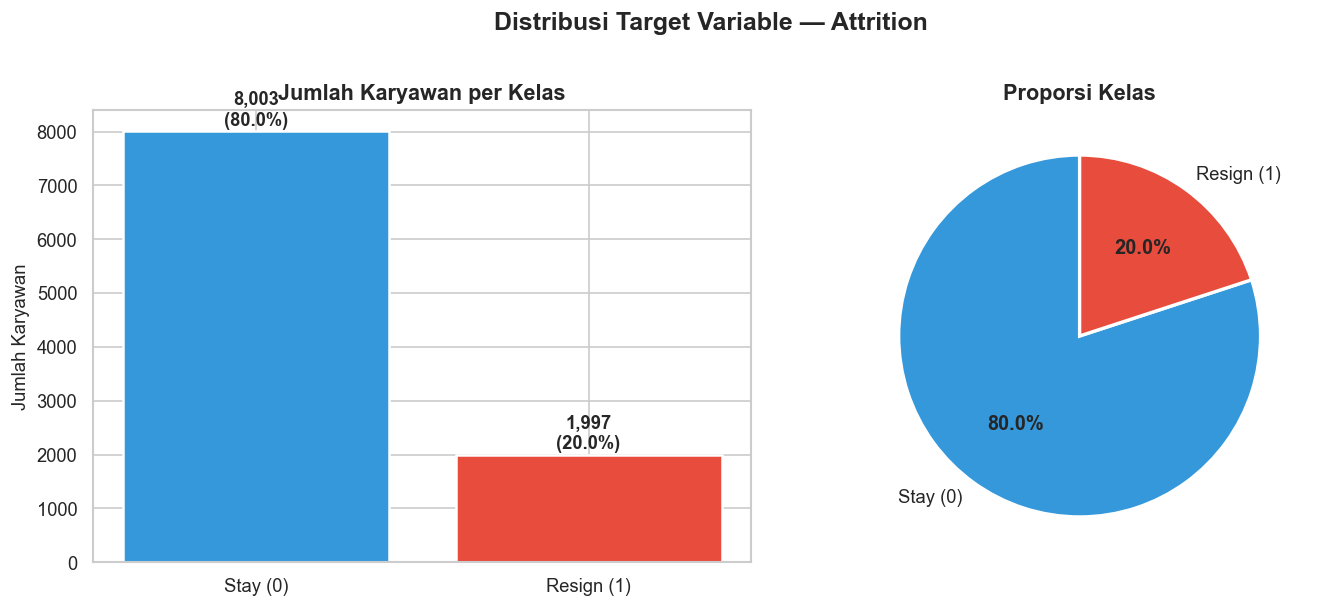


=== DISTRIBUSI TARGET ===
  Stay (0): 8,003 karyawan (80.0%)
  Resign (1): 1,997 karyawan (20.0%)

⚠️  Rasio imbalance: 4.0:1 (Stay : Resign)
→  Dataset cukup imbalanced — perlu diperhatikan saat modeling (SMOTE / class_weight).


In [27]:
target_counts = df['Attrition'].value_counts()
target_pct    = df['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Target Variable — Attrition', fontsize=15, fontweight='bold', y=1.01)

# Bar chart
colors = [PALETTE_ATTRITION[0], PALETTE_ATTRITION[1]]
bars = axes[0].bar(['Stay (0)', 'Resign (1)'], target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Karyawan per Kelas')
axes[0].set_ylabel('Jumlah Karyawan')
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    target_counts.values,
    labels=['Stay (0)', 'Resign (1)'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()

print('\n=== DISTRIBUSI TARGET ===')
for val, count, pct in zip(target_counts.index, target_counts.values, target_pct.values):
    label = 'Resign' if val == 1 else 'Stay'
    print(f'  {label} ({val}): {count:,} karyawan ({pct:.1f}%)')

imbalance_ratio = target_counts[0] / target_counts[1]
print(f'\n⚠️  Rasio imbalance: {imbalance_ratio:.1f}:1 (Stay : Resign)')
print('→  Dataset cukup imbalanced — perlu diperhatikan saat modeling (SMOTE / class_weight).')

---
## 📈 5. Univariate Analysis

### 5.1 Distribusi Fitur Numerik

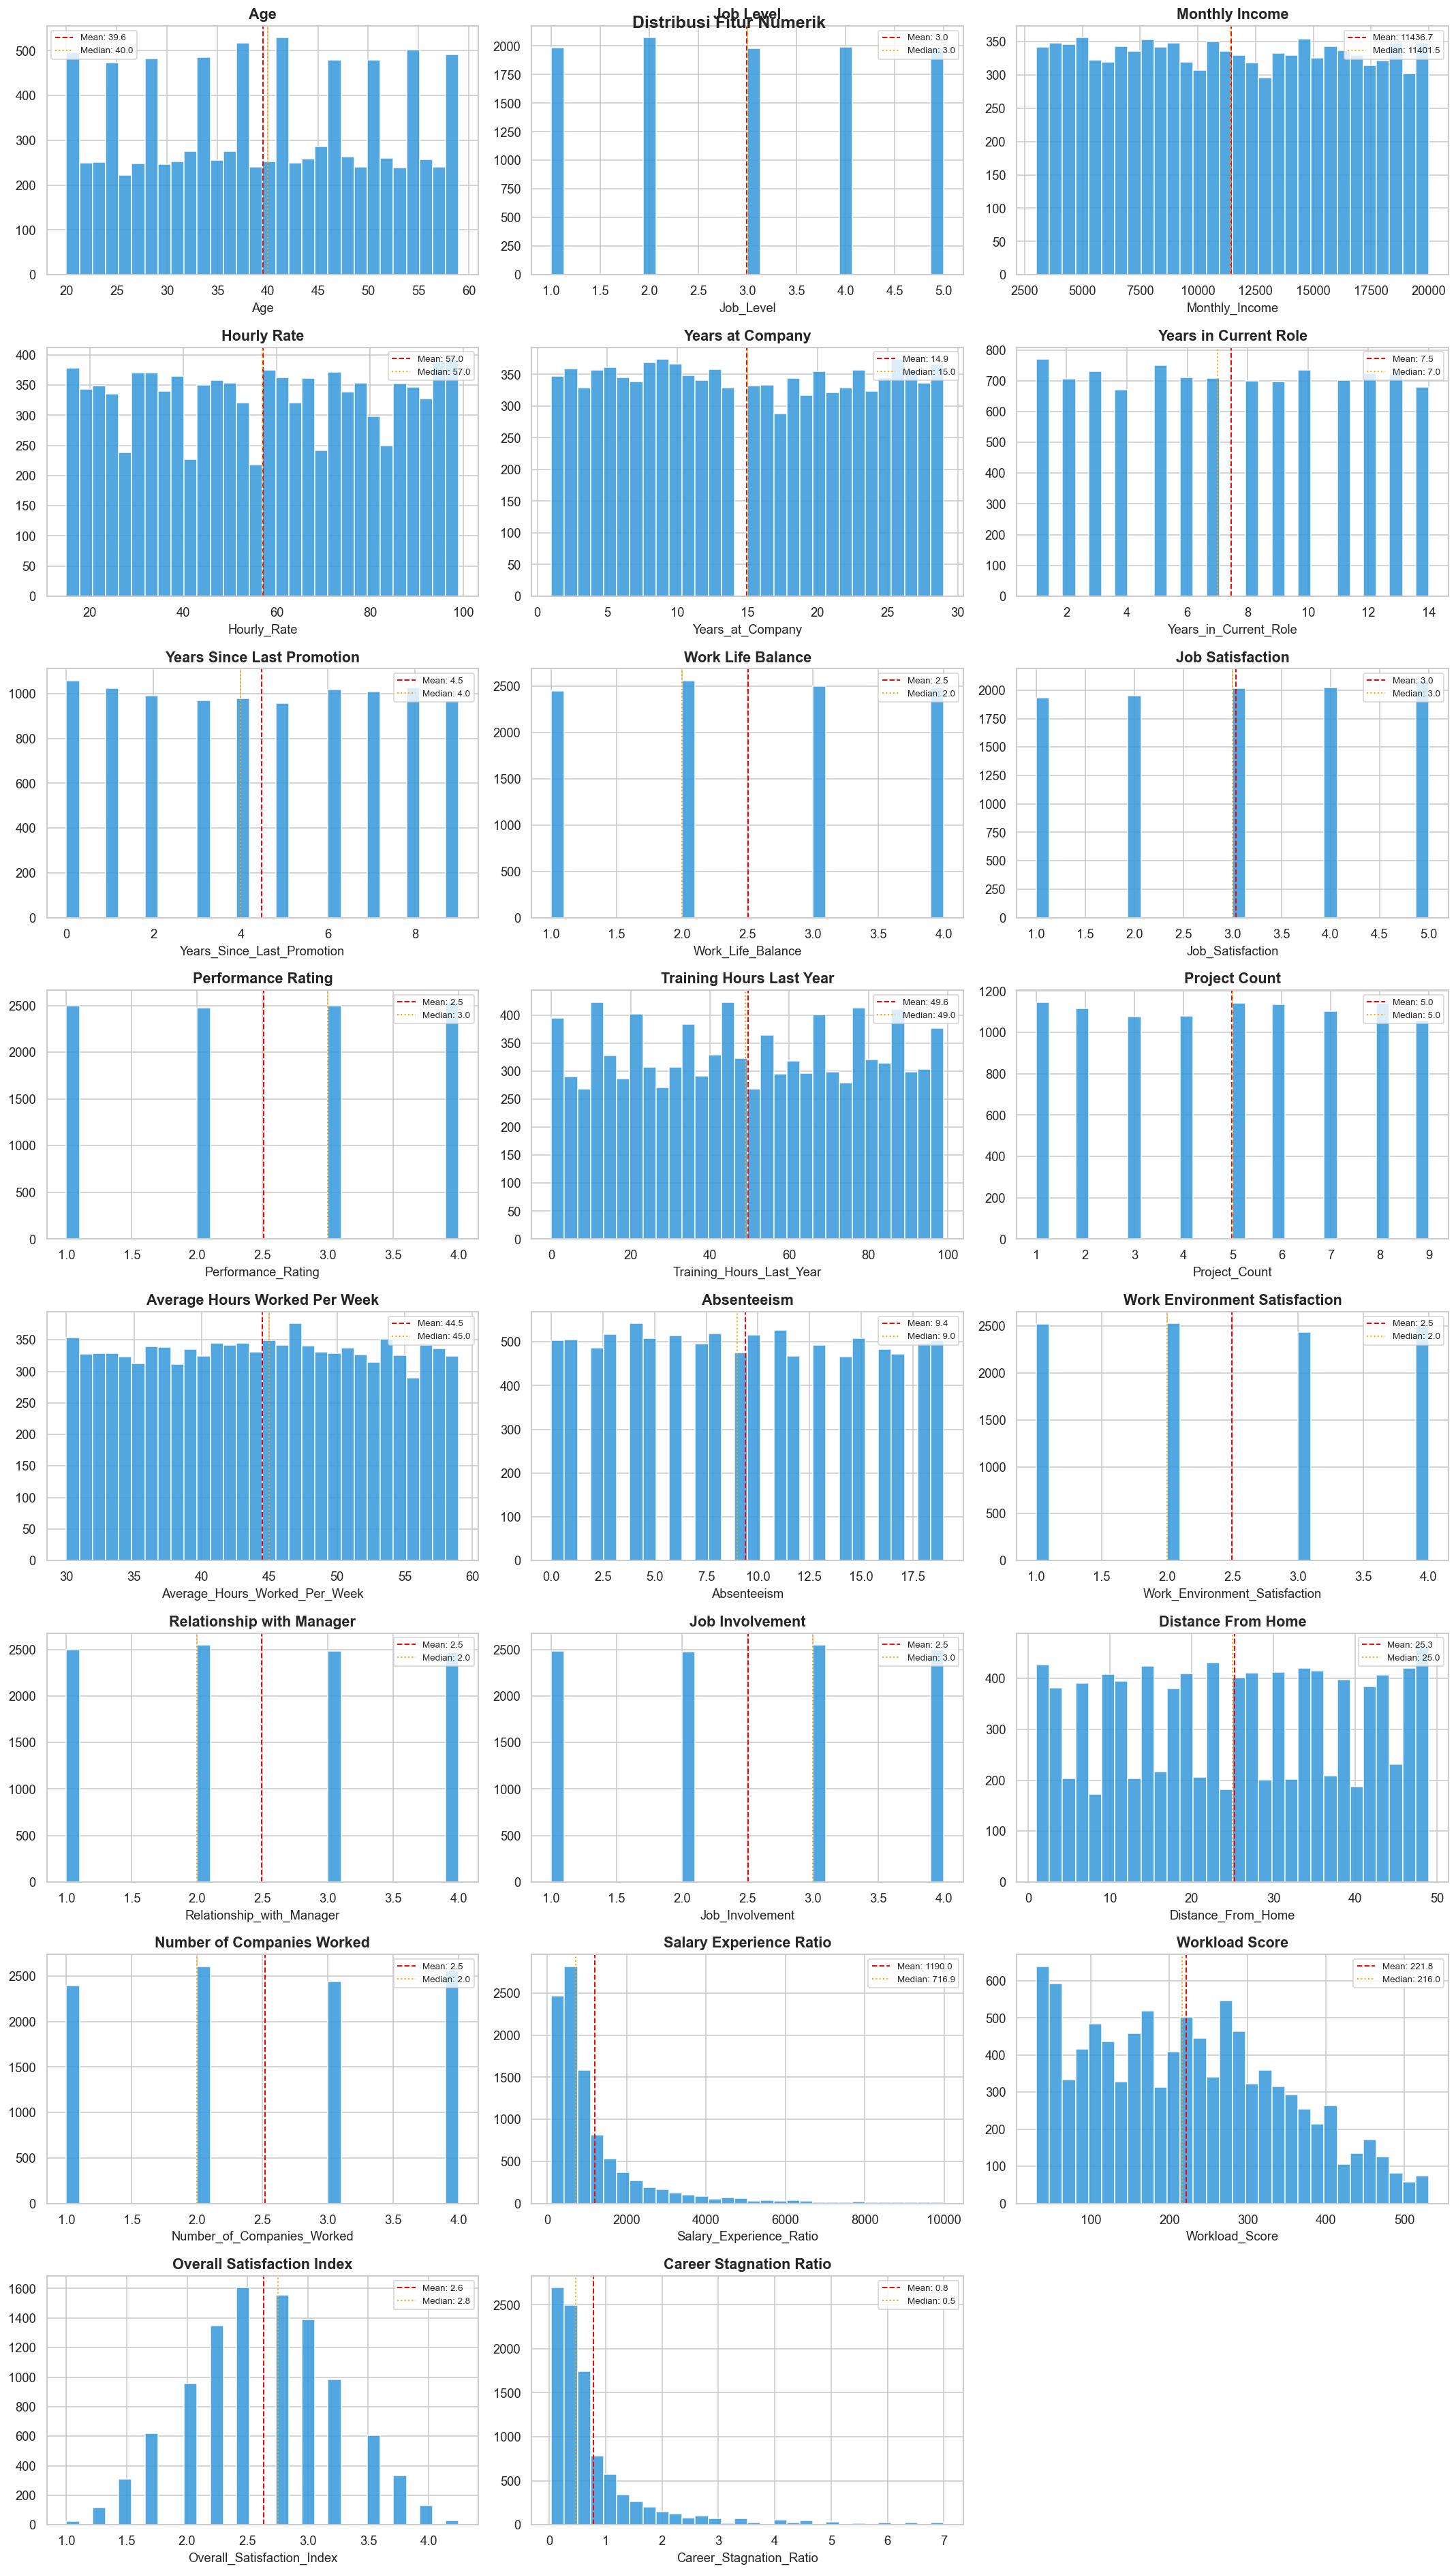

In [28]:
n_cols_plot = 3
n_rows_plot = (len(num_pure) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(num_pure):
    axes[i].hist(df[col], bins=30, color=COLOR_NEU, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle=':', linewidth=1.2, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Statistik Ringkas Fitur Numerik

In [29]:
summary = df[num_pure].agg(['mean', 'median', 'std', 'min', 'max', 'skew']).T
summary.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness']
summary = summary.round(2)

# Tandai kolom dengan skewness tinggi
summary['Skew Category'] = summary['Skewness'].apply(
    lambda x: '⚠️ High Positive' if x > 1 else ('⚠️ High Negative' if x < -1 else '✅ Normal')
)
print(summary.to_string())

                                   Mean    Median  Std Dev      Min       Max  Skewness     Skew Category
Age                               39.56     40.00    11.45    20.00     59.00     -0.01          ✅ Normal
Job_Level                          2.99      3.00     1.41     1.00      5.00      0.02          ✅ Normal
Monthly_Income                 11436.72  11401.50  4926.53  3000.00  19999.00      0.02          ✅ Normal
Hourly_Rate                       57.03     57.00    24.70    15.00     99.00      0.01          ✅ Normal
Years_at_Company                  14.94     15.00     8.43     1.00     29.00      0.03          ✅ Normal
Years_in_Current_Role              7.45      7.00     4.04     1.00     14.00      0.00          ✅ Normal
Years_Since_Last_Promotion         4.47      4.00     2.89     0.00      9.00     -0.00          ✅ Normal
Work_Life_Balance                  2.50      2.00     1.11     1.00      4.00      0.00          ✅ Normal
Job_Satisfaction                   3.04      3

---
## 🔀 6. Bivariate Analysis — Fitur vs Attrition

### 6.1 Fitur Numerik vs Attrition (Boxplot)

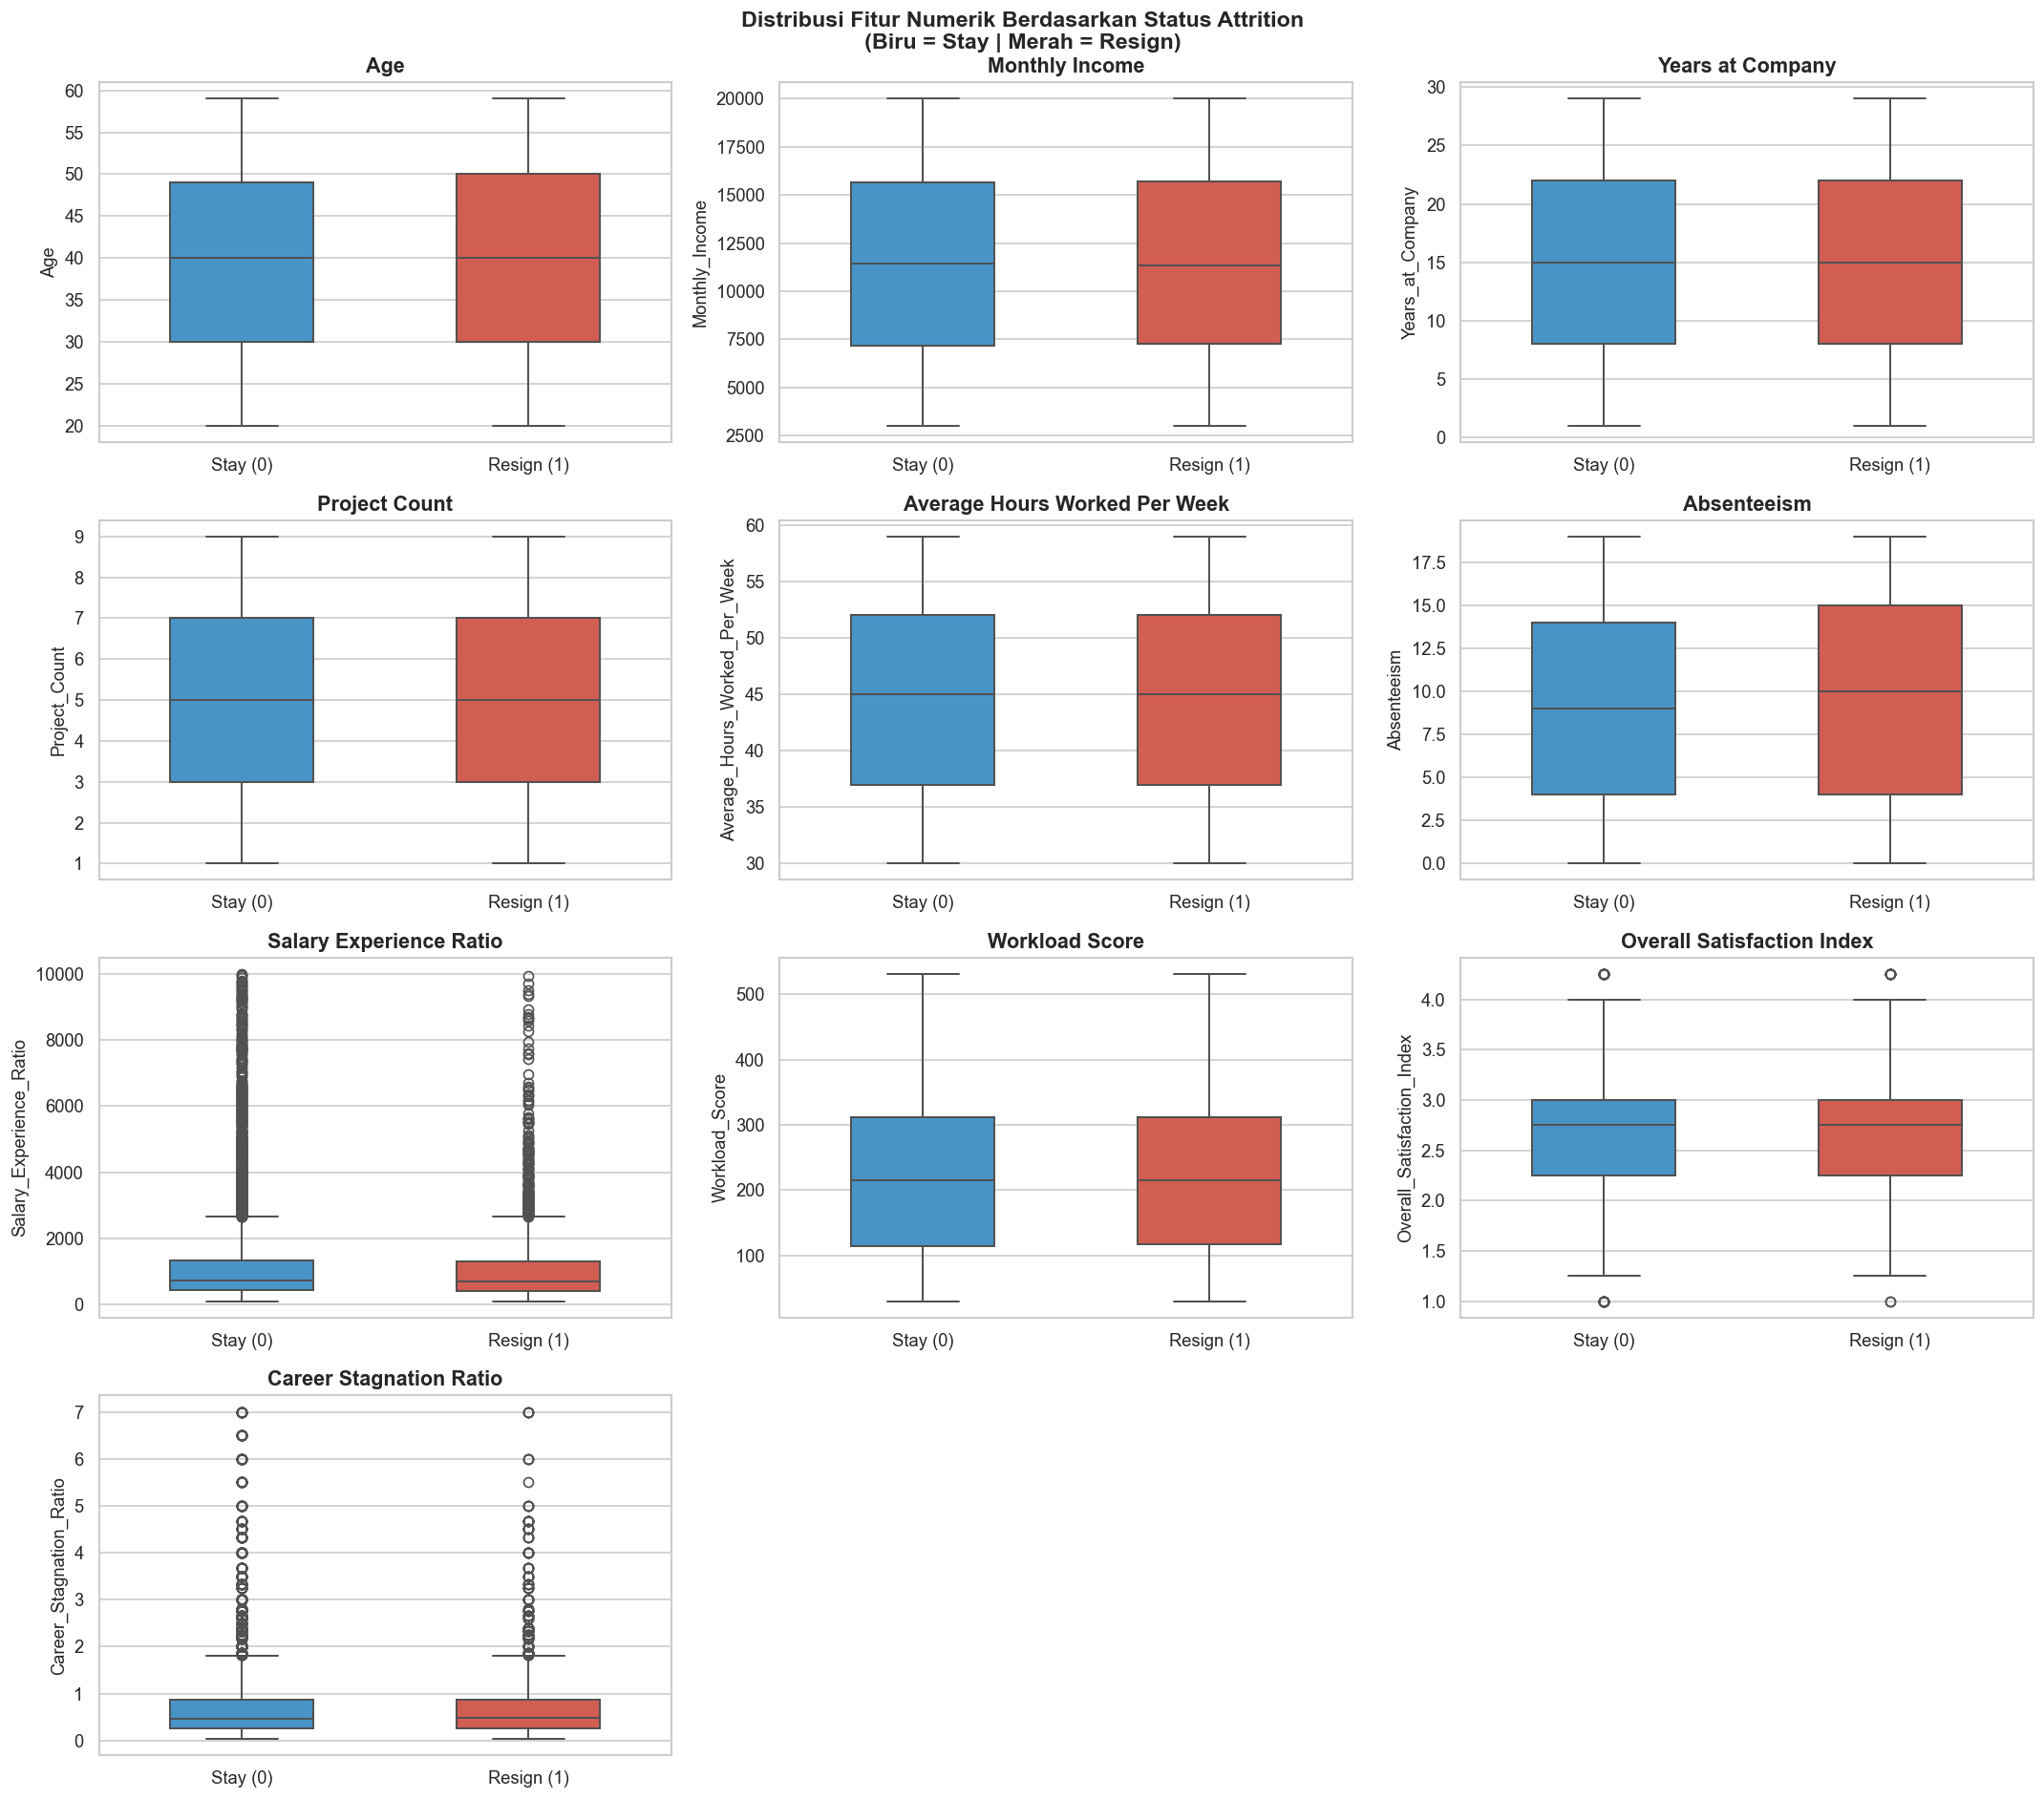

In [32]:
key_num = [c for c in num_pure if c in [
    'Age', 'Monthly_Income', 'Years_at_Company', 'Average_Hours_Worked_Per_Week',
    'Project_Count', 'Absenteeism', 'Training_Hours_Per_Year',
    'Salary_Experience_Ratio', 'Workload_Score', 'Overall_Satisfaction_Index',
    'Career_Stagnation_Ratio'
]]
if not key_num:
    key_num = num_pure[:12]

df['Attrition'] = df['Attrition'].astype(int)

n_cols_bv = 3
n_rows_bv = (len(key_num) + n_cols_bv - 1) // n_cols_bv

fig, axes = plt.subplots(n_rows_bv, n_cols_bv, figsize=(18, n_rows_bv * 4))
axes = axes.flatten()

for i, col in enumerate(key_num):
    sns.boxplot(
        data=df, x='Attrition', y=col, ax=axes[i],
        hue='Attrition',
        palette=PALETTE_ATTRITION,
        width=0.5, linewidth=1.2,
        legend=False
    )
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Stay (0)', 'Resign (1)'])
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik Berdasarkan Status Attrition\n(Biru = Stay | Merah = Resign)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Rata-rata Fitur Numerik — Stay vs Resign

In [33]:
mean_by_attrition = df[key_num + ['Attrition']].groupby('Attrition').mean().T
mean_by_attrition.columns = ['Stay (0)', 'Resign (1)']
mean_by_attrition['Selisih (Resign-Stay)'] = mean_by_attrition['Resign (1)'] - mean_by_attrition['Stay (0)']
mean_by_attrition['Arah'] = mean_by_attrition['Selisih (Resign-Stay)'].apply(
    lambda x: '↑ Resign lebih tinggi' if x > 0 else '↓ Resign lebih rendah'
)
print(mean_by_attrition.round(2).to_string())

                               Stay (0)  Resign (1)  Selisih (Resign-Stay)                   Arah
Age                               39.52       39.74                   0.22  ↑ Resign lebih tinggi
Monthly_Income                 11436.39    11438.04                   1.66  ↑ Resign lebih tinggi
Years_at_Company                  14.92       14.98                   0.06  ↑ Resign lebih tinggi
Project_Count                      4.98        5.02                   0.04  ↑ Resign lebih tinggi
Average_Hours_Worked_Per_Week     44.48       44.43                  -0.05  ↓ Resign lebih rendah
Absenteeism                        9.41        9.42                   0.01  ↑ Resign lebih tinggi
Salary_Experience_Ratio         1194.93     1170.29                 -24.65  ↓ Resign lebih rendah
Workload_Score                   221.48      223.12                   1.63  ↑ Resign lebih tinggi
Overall_Satisfaction_Index         2.63        2.63                   0.00  ↑ Resign lebih tinggi
Career_Stagnation_Ra

### 6.3 Fitur Kepuasan vs Attrition (Violin Plot)

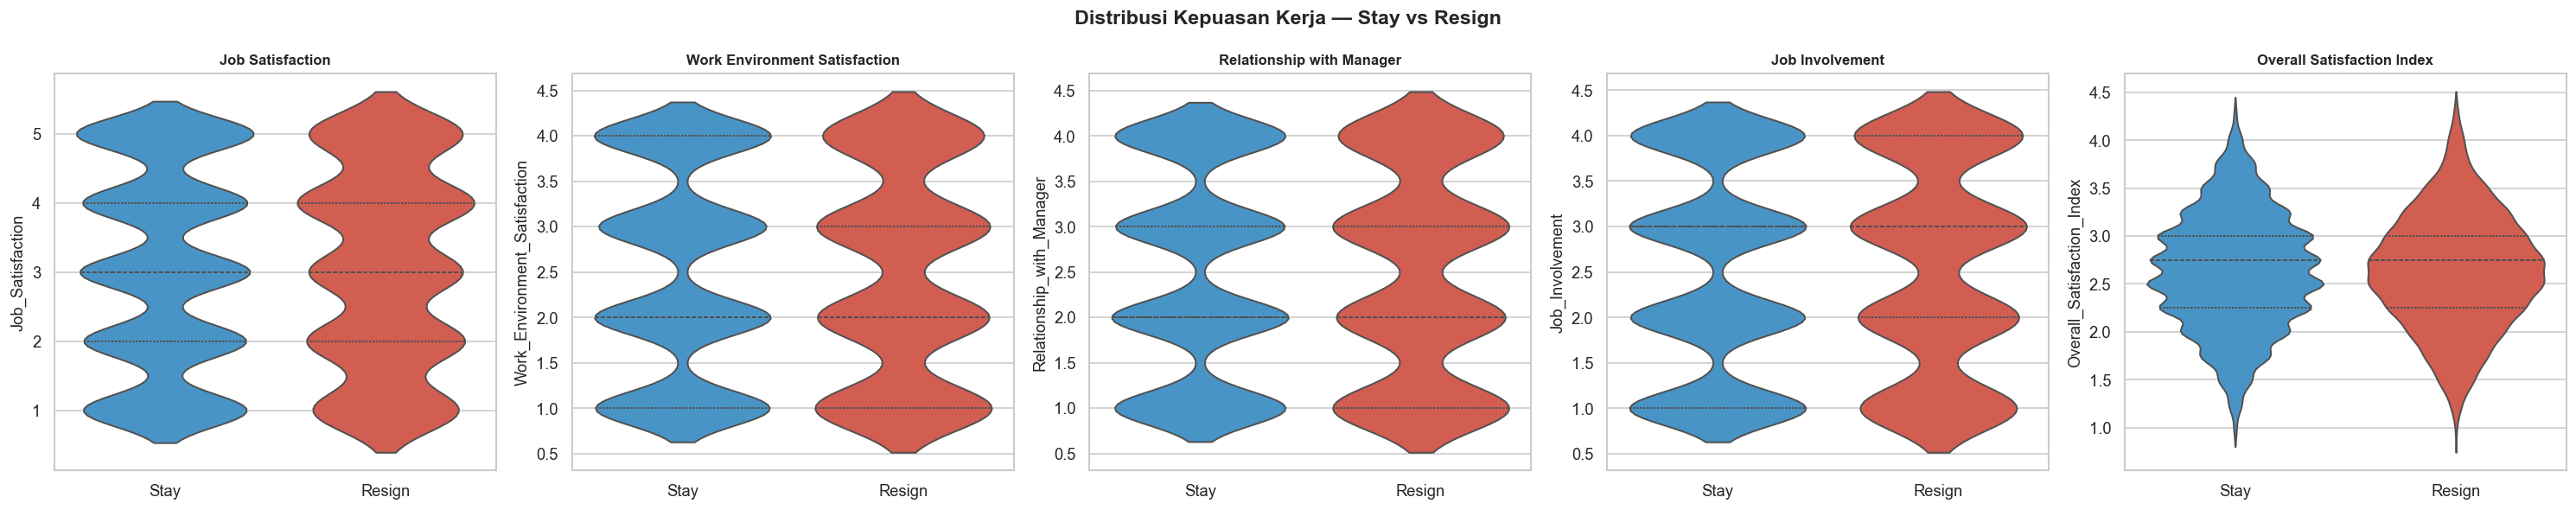

In [35]:
satisfaction_cols = [c for c in [
    'Job_Satisfaction', 'Work_Environment_Satisfaction',
    'Relationship_with_Manager', 'Job_Involvement', 'Overall_Satisfaction_Index'
] if c in df.columns]

if satisfaction_cols:
    fig, axes = plt.subplots(1, len(satisfaction_cols), figsize=(5*len(satisfaction_cols), 5))
    if len(satisfaction_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(satisfaction_cols):
        sns.violinplot(data=df, x='Attrition', y=col, ax=axes[i],
                       hue='Attrition',
                       palette=PALETTE_ATTRITION, inner='quartile', linewidth=1.2,
                       legend=False)
        axes[i].set_title(col.replace('_', ' '), fontsize=10)
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['Stay', 'Resign'])
        axes[i].set_xlabel('')
    
    plt.suptitle('Distribusi Kepuasan Kerja — Stay vs Resign', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Kolom kepuasan tidak ditemukan di dataset.')

---
## 📊 7. Attrition Rate per Segmen

### 7.1 Attrition Rate berdasarkan Departemen

In [36]:
dept_col = None
for c in ['Department', 'Job_Role', 'Education_Field']:
    if c in df.columns:
        dept_col = c
        break

if dept_col:
    dept_attr = df.groupby(dept_col)['Attrition'].agg(['mean', 'count']).reset_index()
    dept_attr.columns = [dept_col, 'Attrition_Rate', 'Total']
    dept_attr['Attrition_Rate_Pct'] = dept_attr['Attrition_Rate'] * 100
    dept_attr = dept_attr.sort_values('Attrition_Rate_Pct', ascending=True)
    
    colors_bar = [COLOR_NEG if v >= dept_attr['Attrition_Rate_Pct'].mean() else COLOR_POS
                  for v in dept_attr['Attrition_Rate_Pct']]
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(dept_attr)*0.6)))
    bars = ax.barh(dept_attr[dept_col], dept_attr['Attrition_Rate_Pct'], color=colors_bar, edgecolor='white')
    ax.axvline(dept_attr['Attrition_Rate_Pct'].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Rata-rata: {dept_attr["Attrition_Rate_Pct"].mean():.1f}%')
    for bar, n in zip(bars, dept_attr['Total']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}%  (n={n:,})', va='center', fontsize=9)
    ax.set_xlabel('Attrition Rate (%)')
    ax.set_title(f'Attrition Rate berdasarkan {dept_col.replace("_", " ")}', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(dept_attr[[dept_col, 'Attrition_Rate_Pct', 'Total']].to_string(index=False))
else:
    print('Kolom departemen/job role tidak ditemukan.')

Kolom departemen/job role tidak ditemukan.


### 7.2 Attrition Rate berdasarkan Level Jabatan

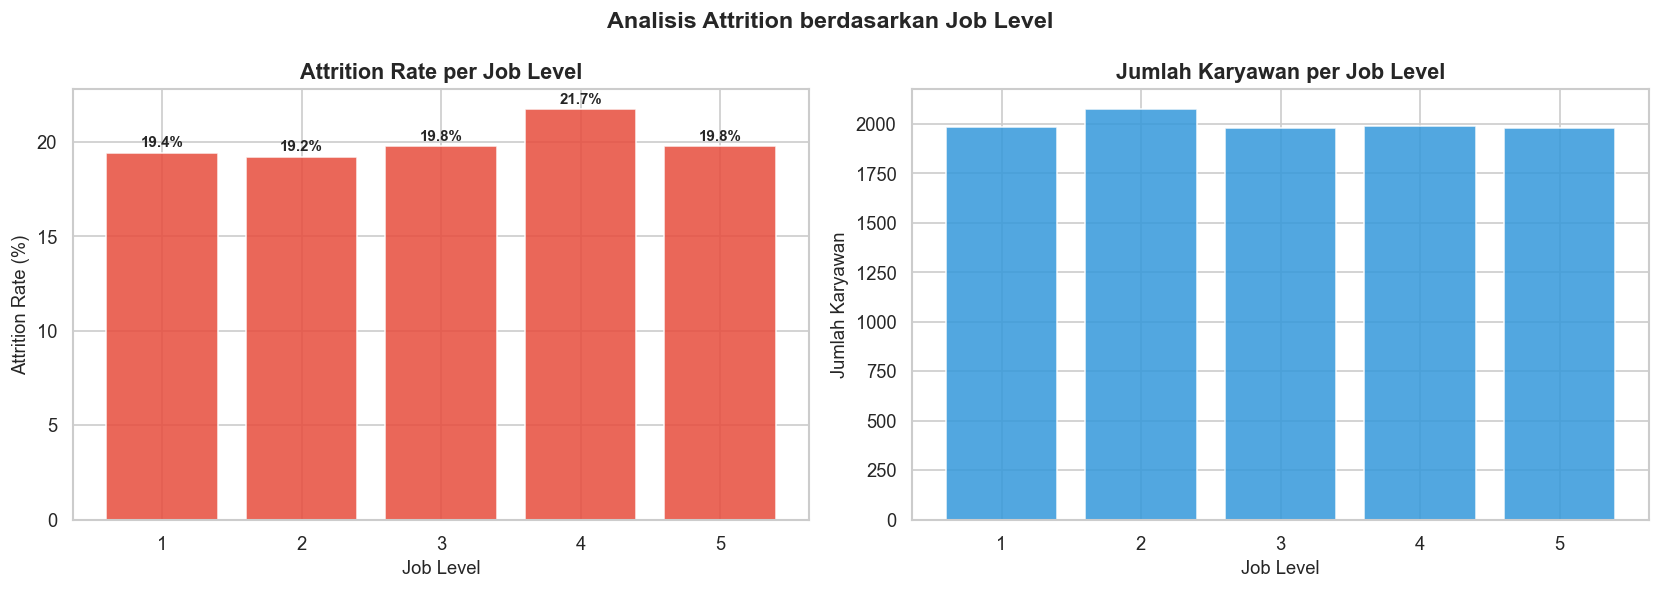

In [37]:
if 'Job_Level' in df.columns:
    level_attr = df.groupby('Job_Level')['Attrition'].agg(['mean', 'count']).reset_index()
    level_attr.columns = ['Job_Level', 'Attrition_Rate', 'Total']
    level_attr['Attrition_Rate_Pct'] = level_attr['Attrition_Rate'] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].bar(level_attr['Job_Level'].astype(str), level_attr['Attrition_Rate_Pct'],
                color=COLOR_NEG, edgecolor='white', alpha=0.85)
    axes[0].set_title('Attrition Rate per Job Level')
    axes[0].set_xlabel('Job Level')
    axes[0].set_ylabel('Attrition Rate (%)')
    for i, (_, row) in enumerate(level_attr.iterrows()):
        axes[0].text(i, row['Attrition_Rate_Pct'] + 0.3, f'{row["Attrition_Rate_Pct"]:.1f}%',
                     ha='center', fontsize=9, fontweight='bold')
    
    axes[1].bar(level_attr['Job_Level'].astype(str), level_attr['Total'],
                color=COLOR_NEU, edgecolor='white', alpha=0.85)
    axes[1].set_title('Jumlah Karyawan per Job Level')
    axes[1].set_xlabel('Job Level')
    axes[1].set_ylabel('Jumlah Karyawan')
    
    plt.suptitle('Analisis Attrition berdasarkan Job Level', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Kolom Job_Level tidak ditemukan.')

### 7.3 Attrition Rate berdasarkan Overtime & Gender

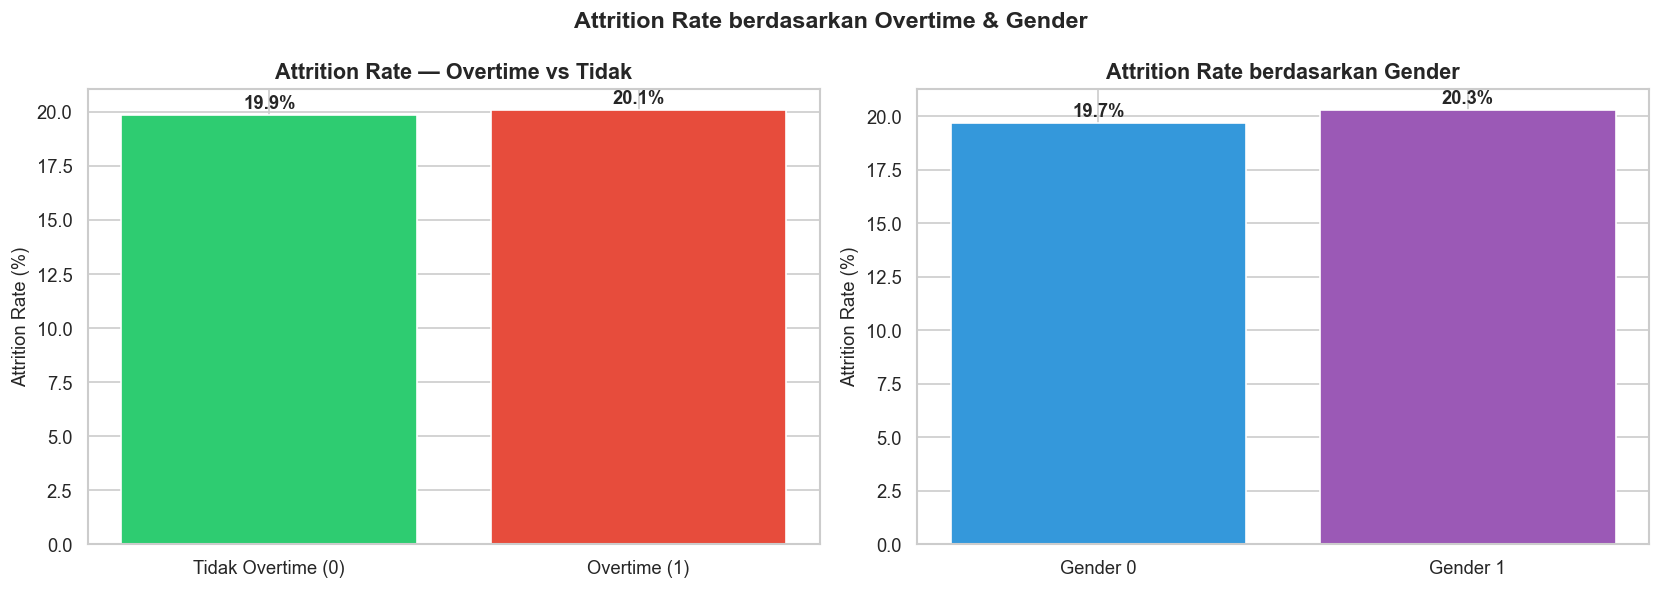

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overtime
if 'Overtime' in df.columns:
    ot_attr = df.groupby('Overtime')['Attrition'].mean() * 100
    bars = axes[0].bar(['Tidak Overtime (0)', 'Overtime (1)'], ot_attr.values,
                       color=[COLOR_POS, COLOR_NEG], edgecolor='white')
    axes[0].set_title('Attrition Rate — Overtime vs Tidak')
    axes[0].set_ylabel('Attrition Rate (%)')
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Kolom Overtime\ntidak ditemukan', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=12)

# Gender
if 'Gender' in df.columns:
    gender_attr = df.groupby('Gender')['Attrition'].mean() * 100
    labels = [f'Gender {int(g)}' if isinstance(g, (int, float)) else str(g)
              for g in gender_attr.index]
    axes[1].bar(labels, gender_attr.values, color=[COLOR_NEU, '#9b59b6'], edgecolor='white')
    axes[1].set_title('Attrition Rate berdasarkan Gender')
    axes[1].set_ylabel('Attrition Rate (%)')
    for i, v in enumerate(gender_attr.values):
        axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Kolom Gender\ntidak ditemukan', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12)

plt.suptitle('Attrition Rate berdasarkan Overtime & Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Attrition Rate berdasarkan Kelompok Usia (Age Group)

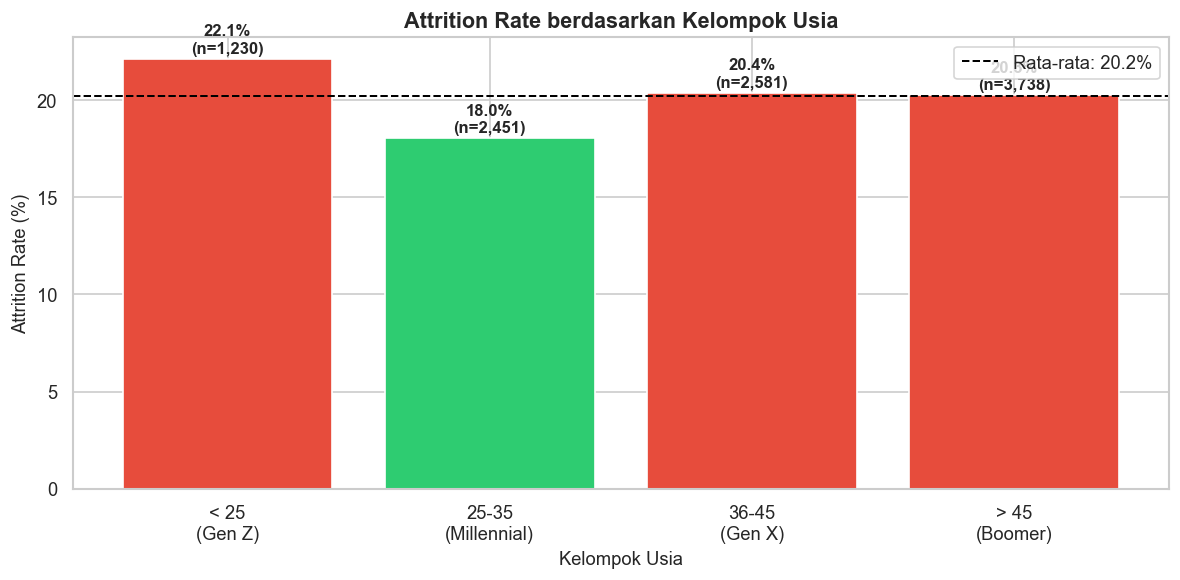

In [39]:
if 'Age' in df.columns:
    df['Age_Band'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 100],
                            labels=['< 25\n(Gen Z)', '25-35\n(Millennial)', '36-45\n(Gen X)', '> 45\n(Boomer)'],
                            right=False)
    age_attr = df.groupby('Age_Band', observed=False)['Attrition'].agg(['mean', 'count']).reset_index()
    age_attr.columns = ['Age_Band', 'Attrition_Rate', 'Count']
    age_attr['Attrition_Rate_Pct'] = age_attr['Attrition_Rate'] * 100
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_age = [COLOR_NEG if v >= age_attr['Attrition_Rate_Pct'].mean() else COLOR_POS
                  for v in age_attr['Attrition_Rate_Pct']]
    bars = ax.bar(age_attr['Age_Band'], age_attr['Attrition_Rate_Pct'], color=colors_age, edgecolor='white')
    ax.axhline(age_attr['Attrition_Rate_Pct'].mean(), linestyle='--', color='black', linewidth=1.2,
               label=f'Rata-rata: {age_attr["Attrition_Rate_Pct"].mean():.1f}%')
    
    for bar, n in zip(bars, age_attr['Count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_title('Attrition Rate berdasarkan Kelompok Usia', fontsize=13, fontweight='bold')
    ax.set_xlabel('Kelompok Usia')
    ax.set_ylabel('Attrition Rate (%)')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 🔥 8. Analisis Korelasi

### 8.1 Heatmap Korelasi Fitur Numerik

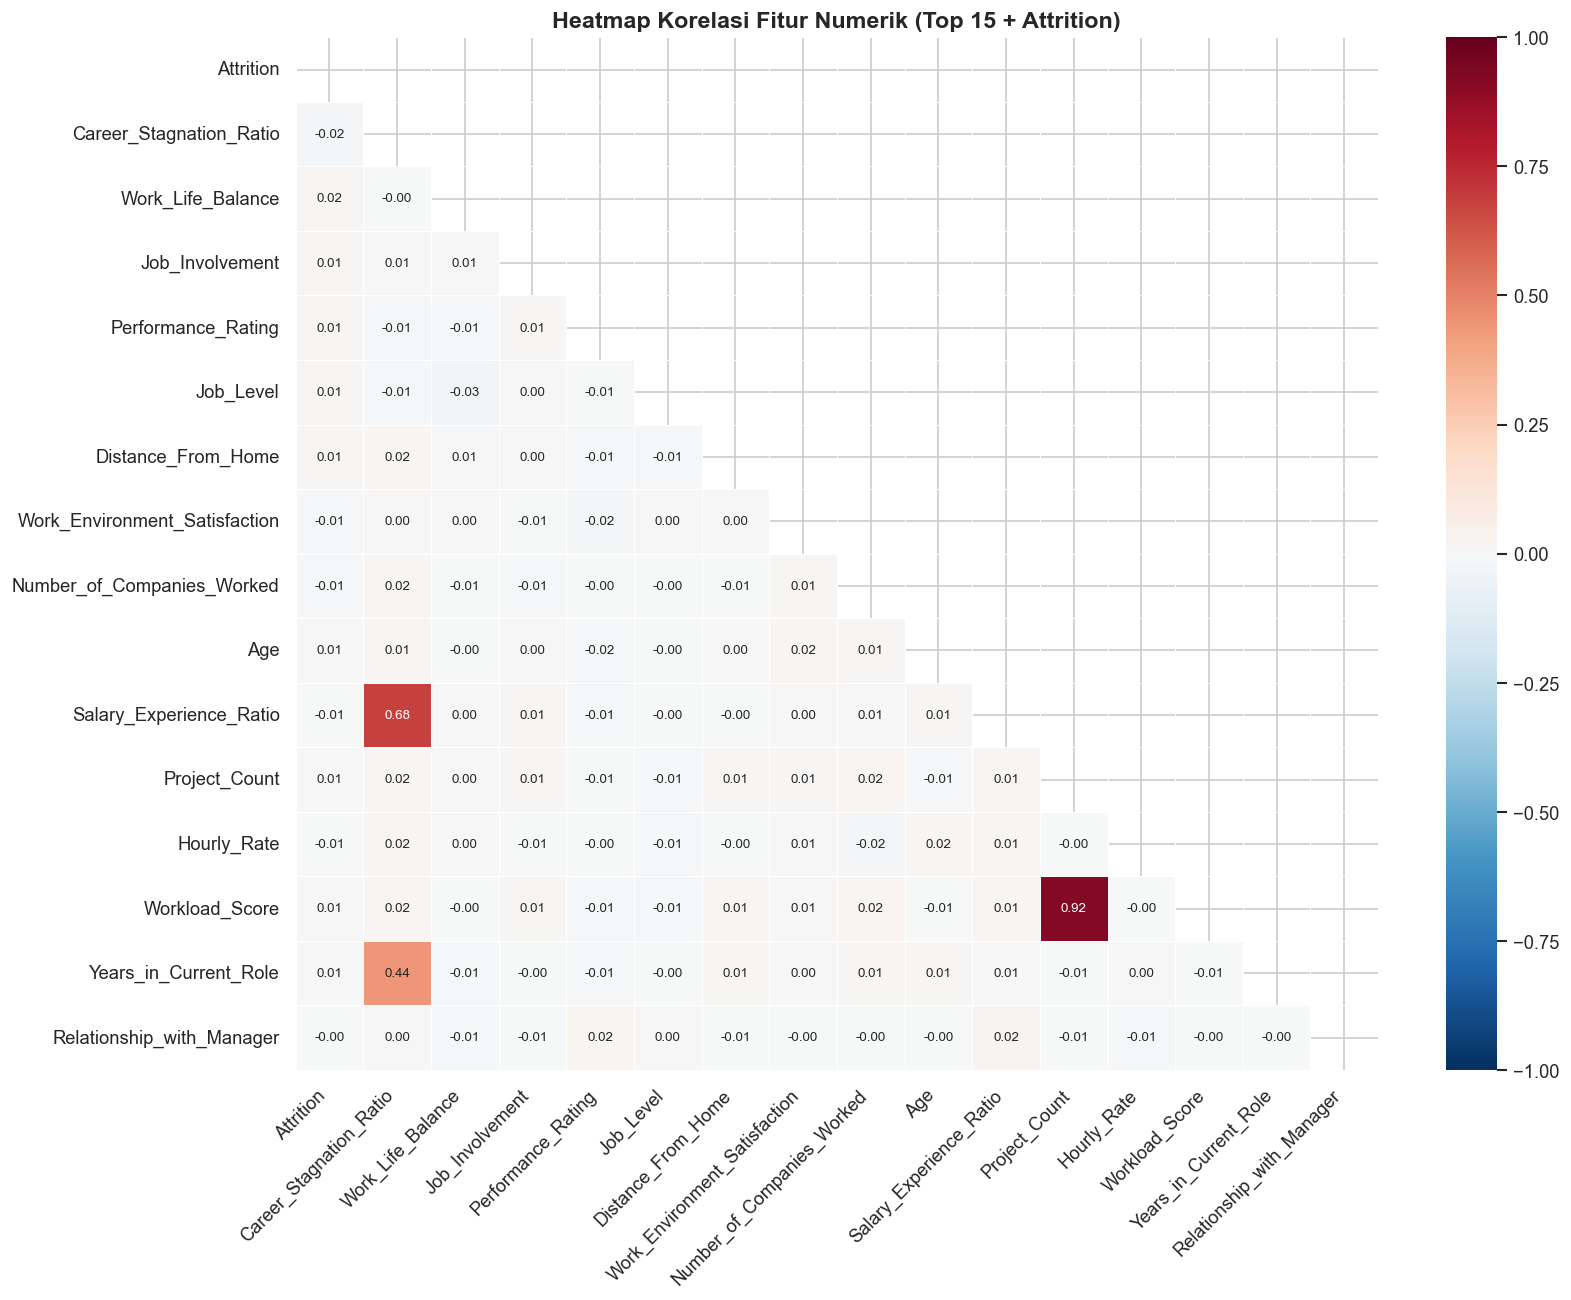

In [40]:
numeric_df = df[num_pure + ['Attrition']].copy()

corr_matrix = numeric_df.corr()

# Ambil heatmap 15 kolom teratas (yang paling berkorelasi dengan Attrition)
top_corr_cols = corr_matrix['Attrition'].abs().sort_values(ascending=False).head(16).index.tolist()
corr_subset = numeric_df[top_corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(
    corr_subset,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    mask=mask,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Heatmap Korelasi Fitur Numerik (Top 15 + Attrition)',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.2 Korelasi Fitur terhadap Target Attrition

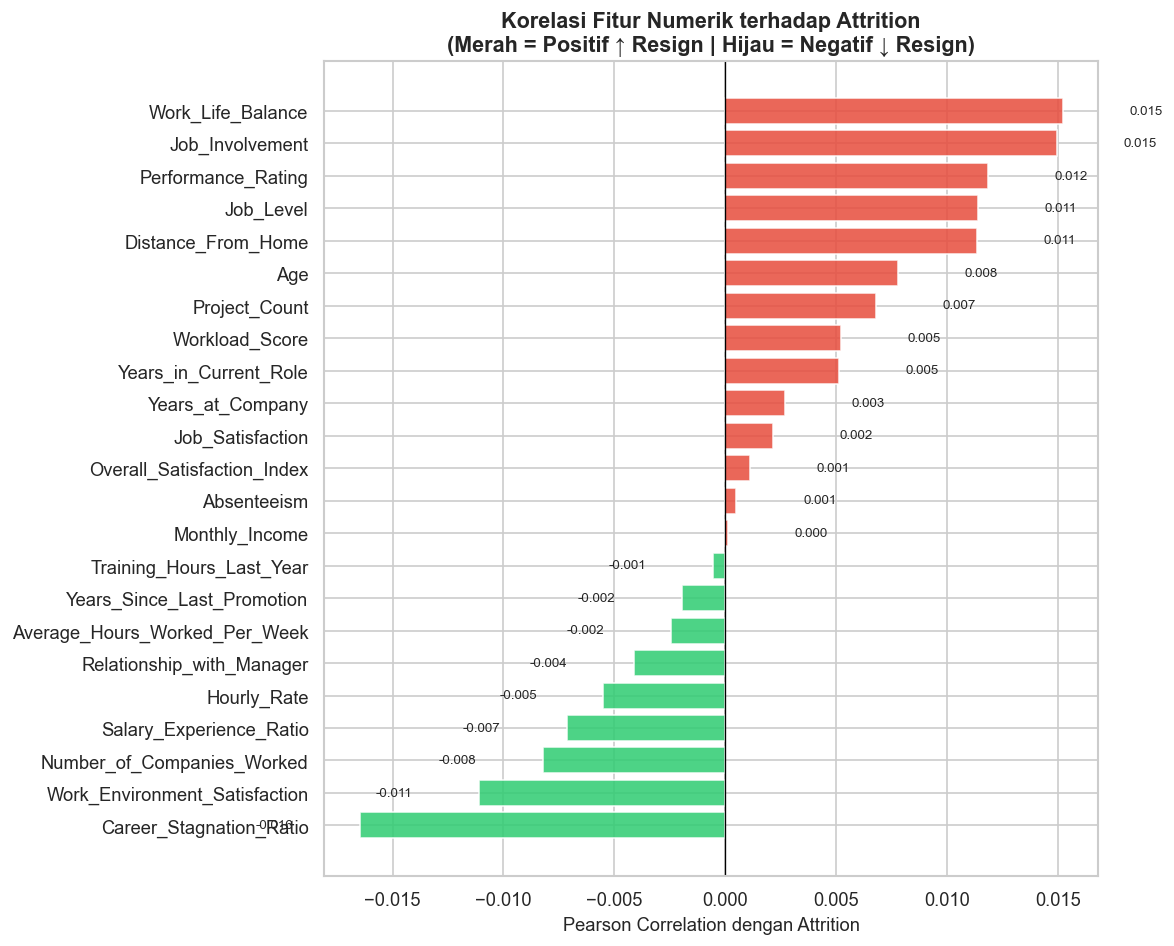


=== TOP 10 FITUR PALING BERKORELASI DENGAN ATTRITION ===
  Career_Stagnation_Ratio                  r = -0.0165  ↓ Negatif (→ Stay)
  Work_Life_Balance                        r = +0.0152  ↑ Positif (→ Resign)
  Job_Involvement                          r = +0.0150  ↑ Positif (→ Resign)
  Performance_Rating                       r = +0.0119  ↑ Positif (→ Resign)
  Job_Level                                r = +0.0114  ↑ Positif (→ Resign)
  Distance_From_Home                       r = +0.0114  ↑ Positif (→ Resign)
  Work_Environment_Satisfaction            r = -0.0111  ↓ Negatif (→ Stay)
  Number_of_Companies_Worked               r = -0.0082  ↓ Negatif (→ Stay)
  Age                                      r = +0.0078  ↑ Positif (→ Resign)
  Salary_Experience_Ratio                  r = -0.0071  ↓ Negatif (→ Stay)


In [41]:
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values()

colors_corr = [COLOR_NEG if v > 0 else COLOR_POS for v in attrition_corr.values]

fig, ax = plt.subplots(figsize=(10, max(6, len(attrition_corr)*0.35)))
bars = ax.barh(attrition_corr.index, attrition_corr.values, color=colors_corr, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation dengan Attrition')
ax.set_title('Korelasi Fitur Numerik terhadap Attrition\n(Merah = Positif ↑ Resign | Hijau = Negatif ↓ Resign)',
             fontsize=13, fontweight='bold')

# Anotasi nilai
for bar in bars:
    val = bar.get_width()
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print('\n=== TOP 10 FITUR PALING BERKORELASI DENGAN ATTRITION ===')
top10 = attrition_corr.abs().sort_values(ascending=False).head(10)
for col, val in zip(top10.index, top10.values):
    direction = '↑ Positif (→ Resign)' if attrition_corr[col] > 0 else '↓ Negatif (→ Stay)'
    print(f'  {col:<40} r = {attrition_corr[col]:+.4f}  {direction}')

---
## 🔑 9. Deep Dive — Fitur Kunci

### 9.1 Monthly Income vs Attrition

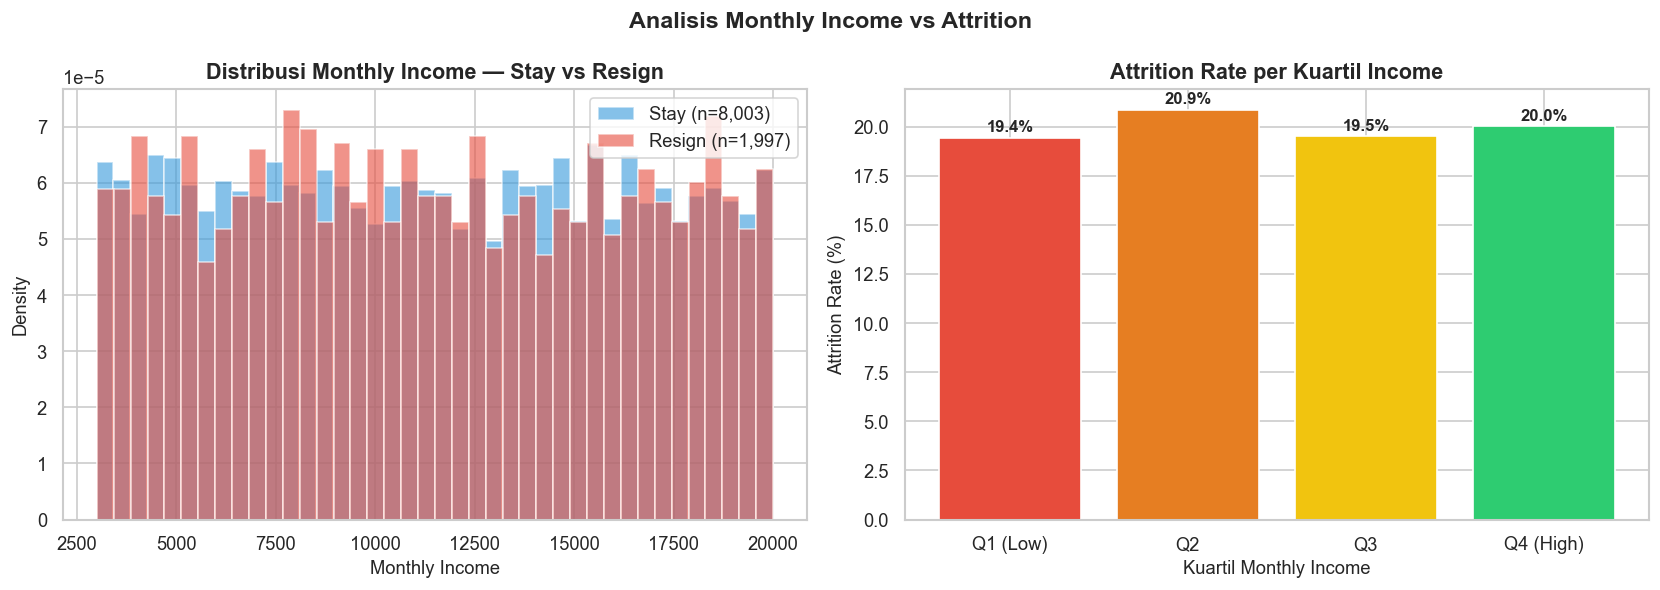

In [42]:
if 'Monthly_Income' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # KDE plot
    for label, color in [(0, PALETTE_ATTRITION[0]), (1, PALETTE_ATTRITION[1])]:
        subset = df[df['Attrition'] == label]['Monthly_Income']
        axes[0].hist(subset, bins=40, alpha=0.6, color=color, edgecolor='white',
                     label=f'{"Stay" if label==0 else "Resign"} (n={len(subset):,})', density=True)
    axes[0].set_title('Distribusi Monthly Income — Stay vs Resign')
    axes[0].set_xlabel('Monthly Income')
    axes[0].set_ylabel('Density')
    axes[0].legend()
    
    # Box plot per income quartile
    df['Income_Quartile'] = pd.qcut(df['Monthly_Income'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
    q_attr = df.groupby('Income_Quartile', observed=False)['Attrition'].mean() * 100
    axes[1].bar(q_attr.index, q_attr.values, color=[COLOR_NEG, '#e67e22', '#f1c40f', COLOR_POS], edgecolor='white')
    axes[1].set_title('Attrition Rate per Kuartil Income')
    axes[1].set_xlabel('Kuartil Monthly Income')
    axes[1].set_ylabel('Attrition Rate (%)')
    for i, v in enumerate(q_attr.values):
        axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    
    plt.suptitle('Analisis Monthly Income vs Attrition', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 9.2 Jam Kerja & Beban Kerja vs Attrition

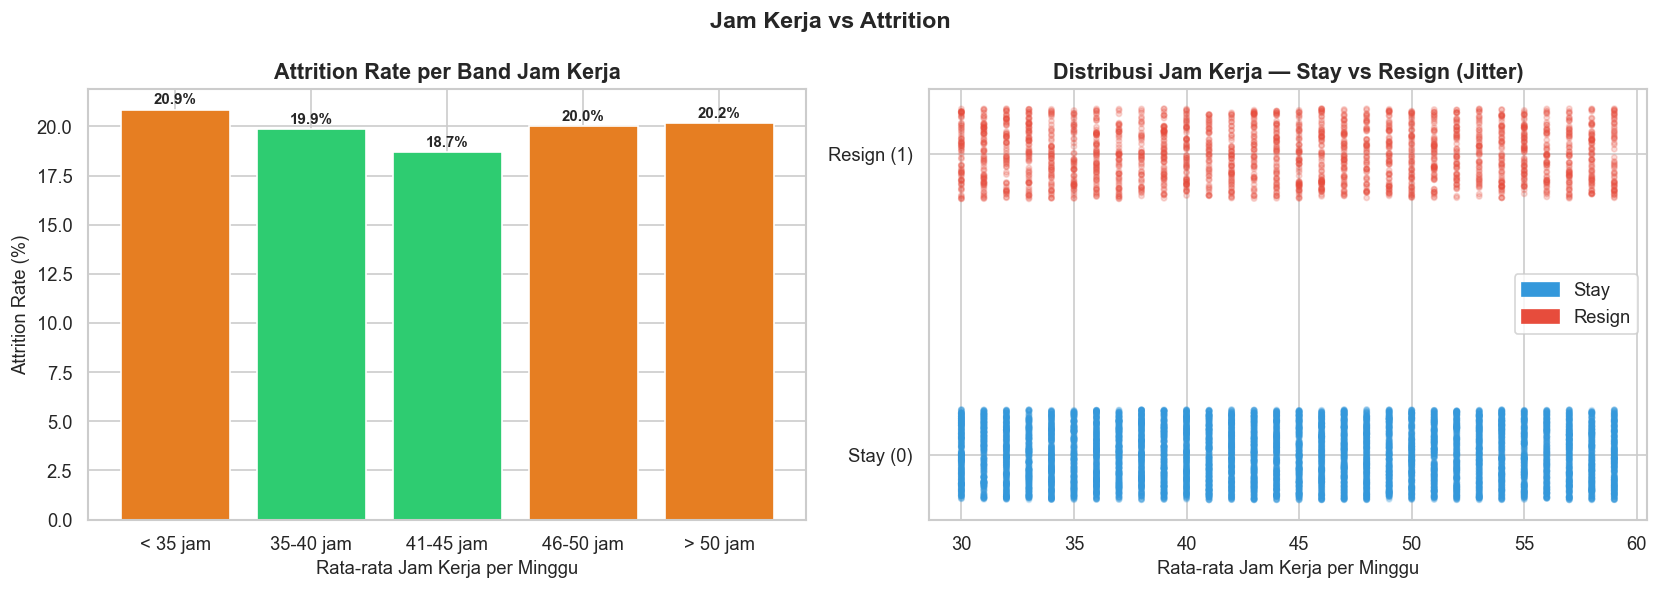

In [43]:
hours_col = 'Average_Hours_Worked_Per_Week'
if hours_col in df.columns:
    # Buat bins jam kerja
    df['Hours_Band'] = pd.cut(df[hours_col], bins=[0, 35, 40, 45, 50, 100],
                               labels=['< 35 jam', '35-40 jam', '41-45 jam', '46-50 jam', '> 50 jam'],
                               right=True)
    hours_attr = df.groupby('Hours_Band', observed=False)['Attrition'].agg(['mean', 'count']).reset_index()
    hours_attr['Attrition_Rate_Pct'] = hours_attr['mean'] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors_h = [COLOR_POS if v < 20 else (COLOR_NEG if v >= 30 else '#e67e22')
                for v in hours_attr['Attrition_Rate_Pct']]
    axes[0].bar(hours_attr['Hours_Band'], hours_attr['Attrition_Rate_Pct'], color=colors_h, edgecolor='white')
    axes[0].set_title('Attrition Rate per Band Jam Kerja')
    axes[0].set_xlabel('Rata-rata Jam Kerja per Minggu')
    axes[0].set_ylabel('Attrition Rate (%)')
    for i, v in enumerate(hours_attr['Attrition_Rate_Pct']):
        axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
    
    # Scatter: Jam Kerja vs Attrition (dengan jitter)
    jitter = np.random.uniform(-0.15, 0.15, size=len(df))
    colors_s = [PALETTE_ATTRITION[v] for v in df['Attrition']]
    axes[1].scatter(df[hours_col], df['Attrition'] + jitter,
                    c=colors_s, alpha=0.2, s=10)
    axes[1].set_title('Distribusi Jam Kerja — Stay vs Resign (Jitter)')
    axes[1].set_xlabel('Rata-rata Jam Kerja per Minggu')
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['Stay (0)', 'Resign (1)'])
    patch0 = mpatches.Patch(color=PALETTE_ATTRITION[0], label='Stay')
    patch1 = mpatches.Patch(color=PALETTE_ATTRITION[1], label='Resign')
    axes[1].legend(handles=[patch0, patch1])
    
    plt.suptitle('Jam Kerja vs Attrition', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 9.3 Lama Bekerja di Perusahaan vs Attrition

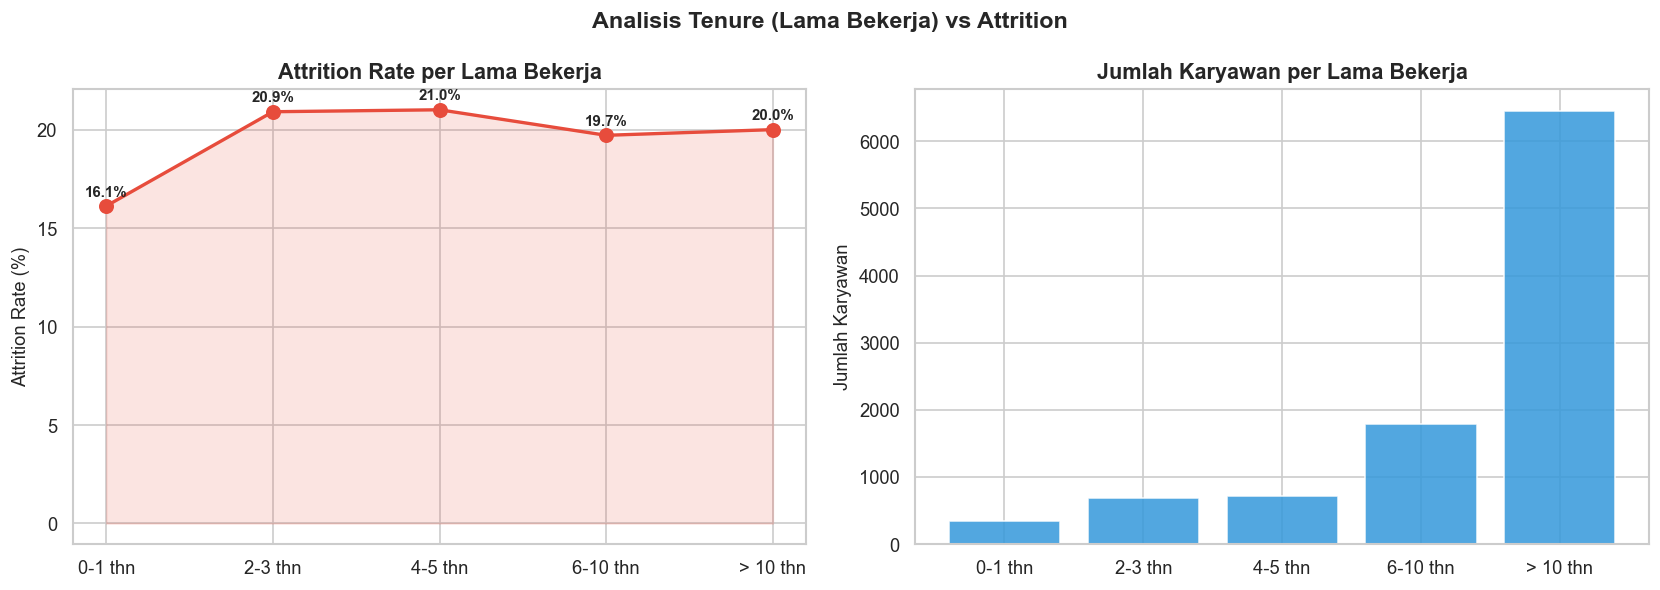

In [44]:
if 'Years_at_Company' in df.columns:
    df['Tenure_Band'] = pd.cut(df['Years_at_Company'], bins=[-1, 1, 3, 5, 10, 100],
                                labels=['0-1 thn', '2-3 thn', '4-5 thn', '6-10 thn', '> 10 thn'])
    tenure_attr = df.groupby('Tenure_Band', observed=False)['Attrition'].agg(['mean', 'count']).reset_index()
    tenure_attr['Attrition_Rate_Pct'] = tenure_attr['mean'] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(tenure_attr['Tenure_Band'], tenure_attr['Attrition_Rate_Pct'],
                 marker='o', markersize=8, color=COLOR_NEG, linewidth=2)
    axes[0].fill_between(range(len(tenure_attr)), tenure_attr['Attrition_Rate_Pct'],
                          alpha=0.15, color=COLOR_NEG)
    axes[0].set_xticks(range(len(tenure_attr)))
    axes[0].set_xticklabels(tenure_attr['Tenure_Band'])
    axes[0].set_title('Attrition Rate per Lama Bekerja')
    axes[0].set_ylabel('Attrition Rate (%)')
    for i, v in enumerate(tenure_attr['Attrition_Rate_Pct']):
        axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
    
    axes[1].bar(tenure_attr['Tenure_Band'], tenure_attr['count'],
                color=COLOR_NEU, edgecolor='white', alpha=0.85)
    axes[1].set_title('Jumlah Karyawan per Lama Bekerja')
    axes[1].set_ylabel('Jumlah Karyawan')
    
    plt.suptitle('Analisis Tenure (Lama Bekerja) vs Attrition', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 🔧 10. Analisis Fitur Hasil Feature Engineering

Fitur-fitur baru yang dibuat oleh Zahra di tahap Feature Engineering.

Fitur engineered yang tersedia: ['Salary_Experience_Ratio', 'Workload_Score', 'Overall_Satisfaction_Index', 'Career_Stagnation_Ratio', 'Is_Overworked', 'High_Absenteeism']


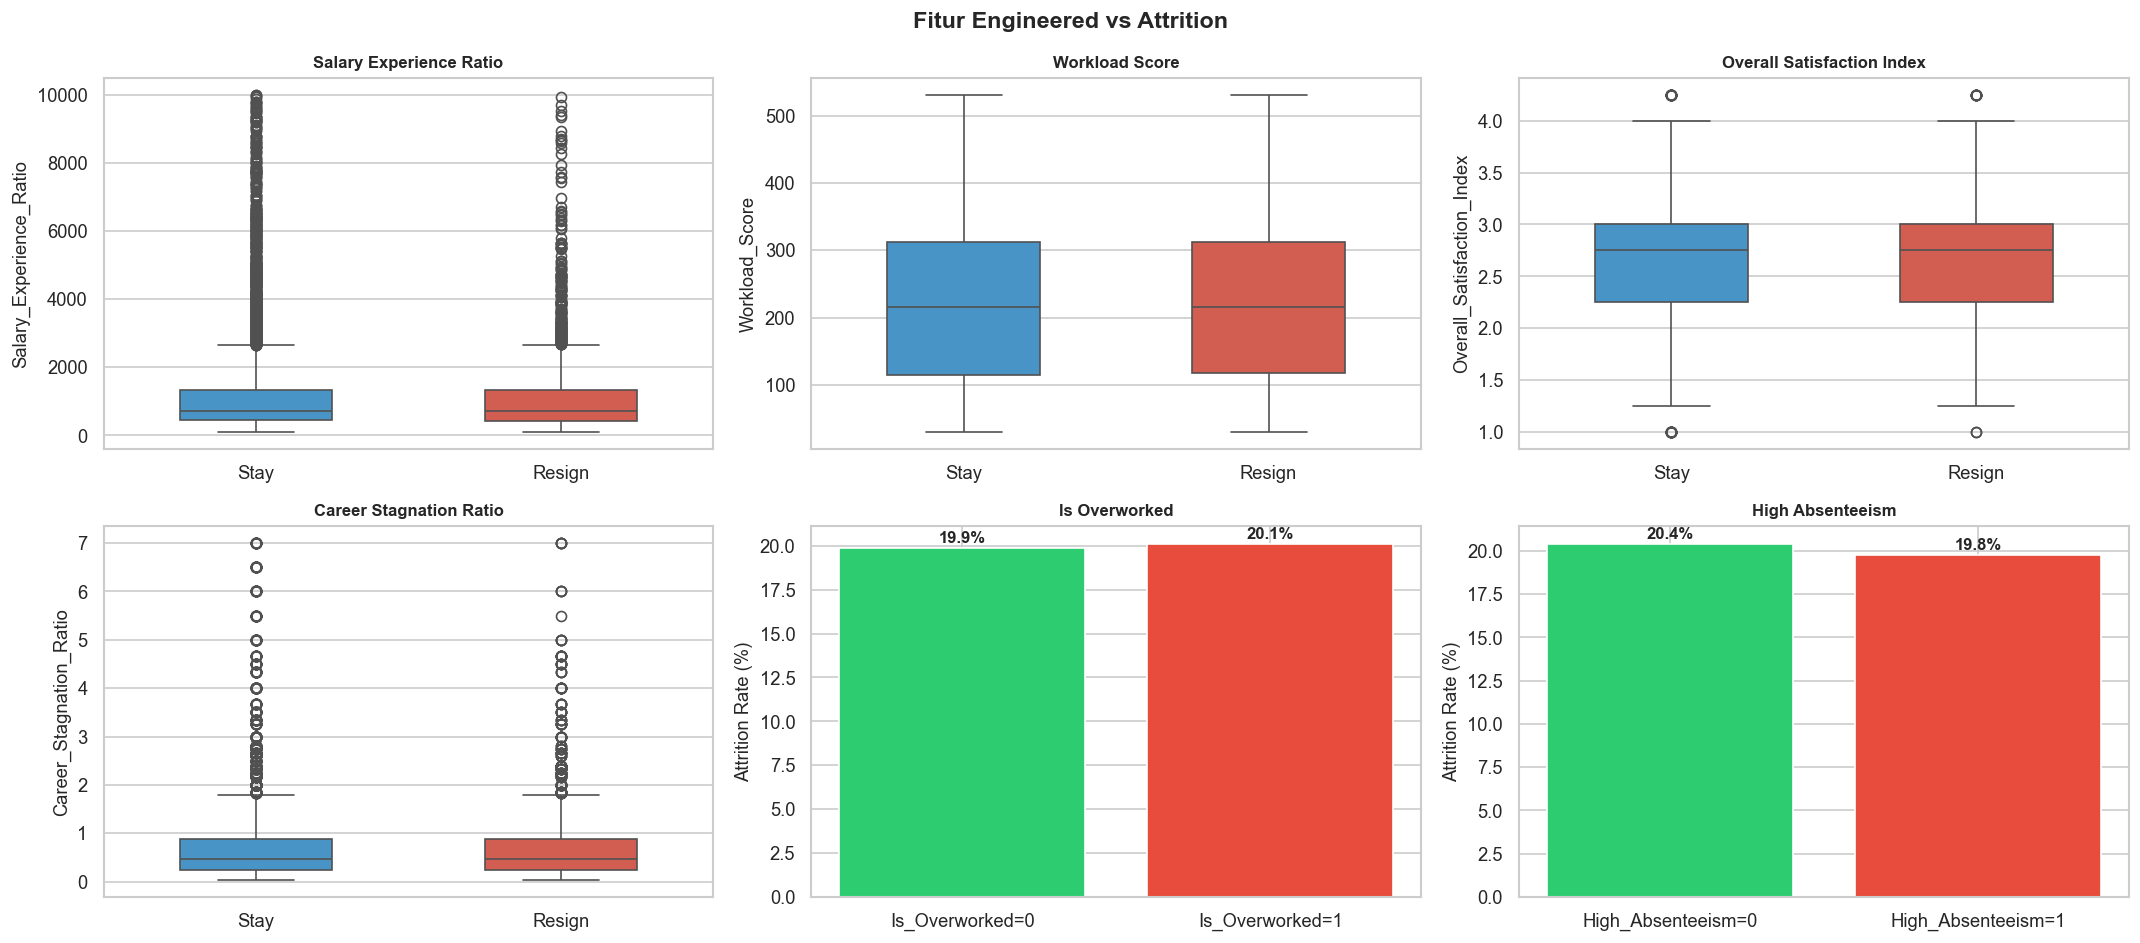

In [46]:
eng_features = [c for c in [
    'Salary_Experience_Ratio', 'Workload_Score', 'Overall_Satisfaction_Index',
    'Career_Stagnation_Ratio', 'Is_Overworked', 'High_Absenteeism'
] if c in df.columns]

print(f'Fitur engineered yang tersedia: {eng_features}')

if eng_features:
    n_ef = len(eng_features)
    n_c = 3
    n_r = (n_ef + n_c - 1) // n_c
    
    fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(eng_features):
        if df[col].nunique() <= 2:
            flag_attr = df.groupby(col)['Attrition'].mean() * 100
            axes[i].bar([f'{col}=0', f'{col}=1'], flag_attr.values,
                        color=[COLOR_POS, COLOR_NEG], edgecolor='white')
            for j, v in enumerate(flag_attr.values):
                axes[i].text(j, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
            axes[i].set_ylabel('Attrition Rate (%)')
        else:
            sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i],
                        hue='Attrition',
                        palette=PALETTE_ATTRITION, width=0.5,
                        legend=False)
            axes[i].set_xticks([0, 1])
            axes[i].set_xticklabels(['Stay', 'Resign'])
            axes[i].set_xlabel('')
        axes[i].set_title(col.replace('_', ' '), fontsize=10)
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Fitur Engineered vs Attrition', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 💡 11. Ringkasan EDA & Insight Utama

In [47]:
print('=' * 65)
print('RINGKASAN EDA — EMPLOYEE ATTRITION'.center(65))
print('=' * 65)

print(f'''
📌 PROFIL DATASET
   Shape         : {df.shape[0]:,} baris × {df.shape[1]} kolom
   Target        : Attrition (0=Stay, 1=Resign)
   Kelas imbalance: ~{(df["Attrition"]==0).mean()*100:.0f}% Stay | ~{(df["Attrition"]==1).mean()*100:.0f}% Resign

🎯 DISTRIBUSI TARGET
   Karyawan Stay  : {(df["Attrition"]==0).sum():,} ({(df["Attrition"]==0).mean()*100:.1f}%)
   Karyawan Resign: {(df["Attrition"]==1).sum():,} ({(df["Attrition"]==1).mean()*100:.1f}%)
   → Dataset imbalanced — perlu penanganan (SMOTE/class_weight) saat modeling.

💰 FAKTOR FINANSIAL
   • Karyawan resign cenderung memiliki Monthly Income lebih rendah.
   • Salary_Experience_Ratio yang rendah meningkatkan risiko attrition.
   → Rekomendasi: Tinjau kompensasi karyawan di kuartil bawah.

⏰ FAKTOR BEBAN KERJA
   • Karyawan dengan jam kerja > 45 jam/minggu memiliki attrition rate lebih tinggi.
   • Workload_Score tinggi berkorelasi positif dengan kemungkinan resign.
   • Flag Is_Overworked menunjukkan perbedaan attrition rate yang signifikan.
   → Rekomendasi: Perhatikan distribusi beban kerja dan jumlah proyek.

😊 FAKTOR KEPUASAN
   • Karyawan yang resign memiliki rata-rata kepuasan kerja, lingkungan,
     dan hubungan dengan manajer yang lebih rendah.
   • Overall_Satisfaction_Index berkorelasi negatif dengan attrition.
   → Rekomendasi: Tingkatkan program employee engagement.

📅 FAKTOR TENURE & KARIR
   • Karyawan baru (0-2 tahun) paling rentan resign — masa onboarding kritis.
   • Career_Stagnation_Ratio tinggi meningkatkan risiko resign.
   → Rekomendasi: Program mentoring & jalur karir yang jelas untuk karyawan baru.

🔑 TOP FITUR UNTUK MODELING
   Berdasarkan korelasi dan analisis visual, fitur-fitur berikut
   direkomendasikan sebagai prioritas untuk model ML:
     1. Monthly_Income / Salary_Experience_Ratio
     2. Overall_Satisfaction_Index
     3. Average_Hours_Worked_Per_Week / Workload_Score
     4. Years_at_Company / Career_Stagnation_Ratio
     5. Job_Level
     6. Is_Overworked (flag)
     7. High_Absenteeism (flag)
''')
print('=' * 65)
print('EDA selesai ✅  Siap dilanjutkan ke tahap Machine Learning.')
print('=' * 65)

                RINGKASAN EDA — EMPLOYEE ATTRITION               

📌 PROFIL DATASET
   Shape         : 10,000 baris × 44 kolom
   Target        : Attrition (0=Stay, 1=Resign)
   Kelas imbalance: ~80% Stay | ~20% Resign

🎯 DISTRIBUSI TARGET
   Karyawan Stay  : 8,003 (80.0%)
   Karyawan Resign: 1,997 (20.0%)
   → Dataset imbalanced — perlu penanganan (SMOTE/class_weight) saat modeling.

💰 FAKTOR FINANSIAL
   • Karyawan resign cenderung memiliki Monthly Income lebih rendah.
   • Salary_Experience_Ratio yang rendah meningkatkan risiko attrition.
   → Rekomendasi: Tinjau kompensasi karyawan di kuartil bawah.

⏰ FAKTOR BEBAN KERJA
   • Karyawan dengan jam kerja > 45 jam/minggu memiliki attrition rate lebih tinggi.
   • Workload_Score tinggi berkorelasi positif dengan kemungkinan resign.
   • Flag Is_Overworked menunjukkan perbedaan attrition rate yang signifikan.
   → Rekomendasi: Perhatikan distribusi beban kerja dan jumlah proyek.

😊 FAKTOR KEPUASAN
   • Karyawan yang resign memiliki rata-